# Car Price Prediction
**Automotive | Machine Learning | Regression**

---

## Objectives
1. Load and inspect a dataset of used car listings with prices in USD
2. Clean the raw data — remove corrupt/placeholder rows, standardise text
3. Perform exploratory data analysis — price distributions, brand trends, depreciation curves
4. Engineer new features — `car_age`, `mileage_per_year`, `make_category`, `price_category`
5. Preprocess data — stratified split, imputation, scaling, one-hot encoding
6. Train and evaluate four models: **Linear Regression**, **Random Forest**, **XGBoost**, **Decision Tree**
7. Compare models using **RMSE** (primary) and **MAE** (secondary)
8. Interpret results — coefficients, feature importances, residuals, boosting curves

---

## Pipeline

| Step | Description |
|---|---|
| **1. Setup** | Install libraries, mount Google Drive |
| **2. Data Gathering** | Load raw CSV, inspect shape and types |
| **3. Data Cleaning** | Remove corrupt rows, convert types, standardise text |
| **4. EDA** | Price distribution, brand analysis, depreciation, correlation |
| **5. Feature Engineering** | Create car_age, mileage_per_year, make_category, price_category |
| **6. Preprocessing** | Stratified split, imputation, scaling, OHE |
| **7. Model Training** | Linear Regression, Random Forest, XGBoost, Decision Tree |
| **8. Prediction & Evaluation** | Scatter plots, residuals, feature importance, best model |

---

## Step 1 — Setup

In [9]:
# Install required libraries
!pip install xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import re

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('All libraries imported successfully.')

All libraries imported successfully.


In [10]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Path to your dataset
DATA_PATH = '/content/drive/MyDrive/cars.csv'
print(f'Data path set to: {DATA_PATH}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data path set to: /content/drive/MyDrive/cars.csv


## Step 2 — Data Gathering

In [11]:
# Load raw CSV
df = pd.read_csv(DATA_PATH)

# Rename columns to remove special characters
df = df.rename(columns={
    'mileage(kilometers)': 'mileage_kilometers',
    'volume(cm3)':         'volume_cm3'
})

initial_count = len(df)
print(f'Rows:    {len(df)}')
print(f'Columns: {len(df.columns)}')

Rows:    56244
Columns: 12


In [12]:
# Data types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56244 entries, 0 to 56243
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make                56244 non-null  object 
 1   model               56244 non-null  object 
 2   priceUSD            56244 non-null  int64  
 3   year                56244 non-null  int64  
 4   condition           56244 non-null  object 
 5   mileage_kilometers  56244 non-null  float64
 6   fuel_type           56244 non-null  object 
 7   volume_cm3          56197 non-null  float64
 8   color               56244 non-null  object 
 9   transmission        56244 non-null  object 
 10  drive_unit          54339 non-null  object 
 11  segment             50953 non-null  object 
dtypes: float64(2), int64(2), object(8)
memory usage: 5.1+ MB


In [13]:
df.head(10)

,make,model,priceUSD,year,condition,mileage_kilometers,fuel_type,volume_cm3,color,transmission,drive_unit,segment
0,mazda,2,5500,2008,with mileage,162000.0,petrol,1500.0,burgundy,mechanics,front-wheel drive,B
1,mazda,2,5350,2009,with mileage,120000.0,petrol,1300.0,black,mechanics,front-wheel drive,B
2,mazda,2,7000,2009,with mileage,61000.0,petrol,1500.0,silver,auto,front-wheel drive,B
3,mazda,2,3300,2003,with mileage,265000.0,diesel,1400.0,white,mechanics,front-wheel drive,B
4,mazda,2,5200,2008,with mileage,97183.0,diesel,1400.0,gray,mechanics,front-wheel drive,B
5,mazda,2,3400,2005,with mileage,150000.0,petrol,1300.0,blue,mechanics,front-wheel drive,B
6,mazda,2,5000,2008,with mileage,112000.0,petrol,1300.0,gray,mechanics,front-wheel drive,B
7,mazda,2,7300,2009,with mileage,95000.0,petrol,1500.0,other,auto,front-wheel drive,B
8,mazda,2,6400,2010,with mileage,93804.0,petrol,1500.0,other,mechanics,front-wheel drive,B
9,mazda,2,6132,2008,with mileage,196511.0,petrol,1500.0,other,auto,front-wheel drive,B


In [14]:
# Descriptive statistics for numeric columns
df.describe().round(2)

,priceUSD,year,mileage_kilometers,volume_cm3
count,56244.00,56244.00,56244.00,56197.00
mean,7415.46,2003.45,244395.63,2104.86
std,8316.96,8.14,321030.67,959.20
min,48.00,1910.00,0.00,500.00
25%,2350.00,1998.00,137000.00,1600.00
50%,5350.00,2004.00,228500.00,1996.00
75%,9807.50,2010.00,310000.00,2300.00
max,235235.00,2019.00,9999999.00,20000.00


In [15]:
# Value counts for categorical columns
categorical_cols = ['make', 'condition', 'fuel_type', 'color', 'transmission', 'drive_unit', 'segment']
for col_name in categorical_cols:
    print(f'\n--- {col_name} ---')
    print(df[col_name].value_counts().head(15).to_string())


--- make ---
make
volkswagen       6861
audi             4030
bmw              4013
opel             3779
renault          3713
mercedes-benz    3541
ford             3078
peugeot          2876
nissan           2233
toyota           2177
mazda            2006
citroen          1991
hyundai          1499
mitsubishi       1350
volvo            1232

--- condition ---
condition
with mileage    55278
with damage       512
for parts         454

--- fuel_type ---
fuel_type
petrol        36405
diesel        19792
electrocar       47

--- color ---
color
black       12385
silver      10075
blue         8083
gray         5807
white        5292
green        3911
other        3397
red          2744
burgundy     2026
brown        1349
purple        625
yellow        317
orange        233

--- transmission ---
transmission
mechanics    36056
auto         20188

--- drive_unit ---
drive_unit
front-wheel drive             38016
rear drive                     6836
all-wheel drive                5890


In [16]:
# Unique counts per column
print('Unique value counts:')
print('=' * 40)
for col_name in df.columns:
    print(f'  {col_name:25s}: {df[col_name].nunique()}')

Unique value counts:
  make                     : 96
  model                    : 1034
  priceUSD                 : 2970
  year                     : 78
  condition                : 3
  mileage_kilometers       : 8400
  fuel_type                : 3
  volume_cm3               : 458
  color                    : 13
  transmission             : 2
  drive_unit               : 4
  segment                  : 9


## Step 3 — Data Cleaning

In [17]:
# Convert volume_cm3 from object to numeric
df['volume_cm3'] = pd.to_numeric(df['volume_cm3'], errors='coerce')

In [18]:
# Check missing values
# Note: we do NOT impute here — imputation is done after the train/test split in Step 6
# to avoid data leakage.
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
make                     0
model                    0
priceUSD                 0
year                     0
condition                0
mileage_kilometers       0
fuel_type                0
volume_cm3              47
color                    0
transmission             0
drive_unit            1905
segment               5291
dtype: int64


In [19]:
before = len(df)

# Remove placeholder mileage values (9,999,999 km) — clearly corrupt data
n1 = (df['mileage_kilometers'] >= 9_999_999).sum()
df = df[df['mileage_kilometers'] < 9_999_999]
print(f'Removed {n1} rows with mileage = 9,999,999 (placeholder values)')

# Remove very low prices (< $100) — clearly corrupt data
n2 = (df['priceUSD'] < 100).sum()
df = df[df['priceUSD'] >= 100]
print(f'Removed {n2} rows with price < $100 (data errors)')

after = len(df)
print(f'\nTotal rows removed: {before - after}')
print(f'Rows remaining: {after}')

Removed 22 rows with mileage = 9,999,999 (placeholder values)
Removed 2 rows with price < $100 (data errors)

Total rows removed: 24
Rows remaining: 56220


In [20]:
# Check and drop duplicated rows
n_duplicates = df.duplicated().sum()
print(f'Duplicated rows found: {n_duplicates}')
df = df.drop_duplicates()
print(f'Rows after dropping duplicates: {len(df)}')

Duplicated rows found: 87
Rows after dropping duplicates: 56133


In [21]:
# Outlier report — IQR method (report only, no removal)
print('Outlier Report (IQR method — 1.5 * IQR rule):')
print('=' * 60)
numeric_cols_check = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = n_out / len(df) * 100
    if n_out > 0:
        print(f'  {col:25s}: {n_out:>5} outliers ({pct:.1f}%) | bounds: [{lower:.1f}, {upper:.1f}]')

Outlier Report (IQR method — 1.5 * IQR rule):
  priceUSD                 :  2457 outliers (4.4%) | bounds: [-8900.0, 21100.0]
  year                     :   257 outliers (0.5%) | bounds: [1980.0, 2028.0]
  mileage_kilometers       :   665 outliers (1.2%) | bounds: [-122500.0, 569500.0]
  volume_cm3               :  3615 outliers (6.4%) | bounds: [550.0, 3350.0]


In [22]:
# Lowercase all string columns for consistency
string_cols = df.select_dtypes(include=['object']).columns.tolist()
for col_name in string_cols:
    df[col_name] = df[col_name].str.lower()

print(f'Lowercased columns: {string_cols}')
df[string_cols].head()

Lowercased columns: ['make', 'model', 'condition', 'fuel_type', 'color', 'transmission', 'drive_unit', 'segment']


,make,model,condition,fuel_type,color,transmission,drive_unit,segment
0,mazda,2,with mileage,petrol,burgundy,mechanics,front-wheel drive,b
1,mazda,2,with mileage,petrol,black,mechanics,front-wheel drive,b
2,mazda,2,with mileage,petrol,silver,auto,front-wheel drive,b
3,mazda,2,with mileage,diesel,white,mechanics,front-wheel drive,b
4,mazda,2,with mileage,diesel,gray,mechanics,front-wheel drive,b


In [23]:
print('=' * 55)
print('CLEANING SUMMARY')
print('=' * 55)
print(f'Original rows: {initial_count}')
print(f'Final rows:    {len(df)}')
print(f'Rows removed:  {initial_count - len(df)}')
print(f'Columns:       {len(df.columns)}')
print(f'\nRemaining null values (will be imputed after split in Step 6):')
null_remaining = df.isnull().sum()
null_remaining = null_remaining[null_remaining > 0]
if len(null_remaining) == 0:
    print('  None')
else:
    for col_name, cnt in null_remaining.items():
        pct = cnt / len(df) * 100
        print(f'  {col_name:25s}: {cnt} ({pct:.1f}%)')
print(f'\nData types:')
print(df.dtypes.to_string())

CLEANING SUMMARY
Original rows: 56244
Final rows:    56133
Rows removed:  111
Columns:       12

Remaining null values (will be imputed after split in Step 6):
  volume_cm3               : 47 (0.1%)
  drive_unit               : 1904 (3.4%)
  segment                  : 5281 (9.4%)

Data types:
make                   object
model                  object
priceUSD                int64
year                    int64
condition              object
mileage_kilometers    float64
fuel_type              object
volume_cm3            float64
color                  object
transmission           object
drive_unit             object
segment                object


## Step 4 — Exploratory Data Analysis (EDA)

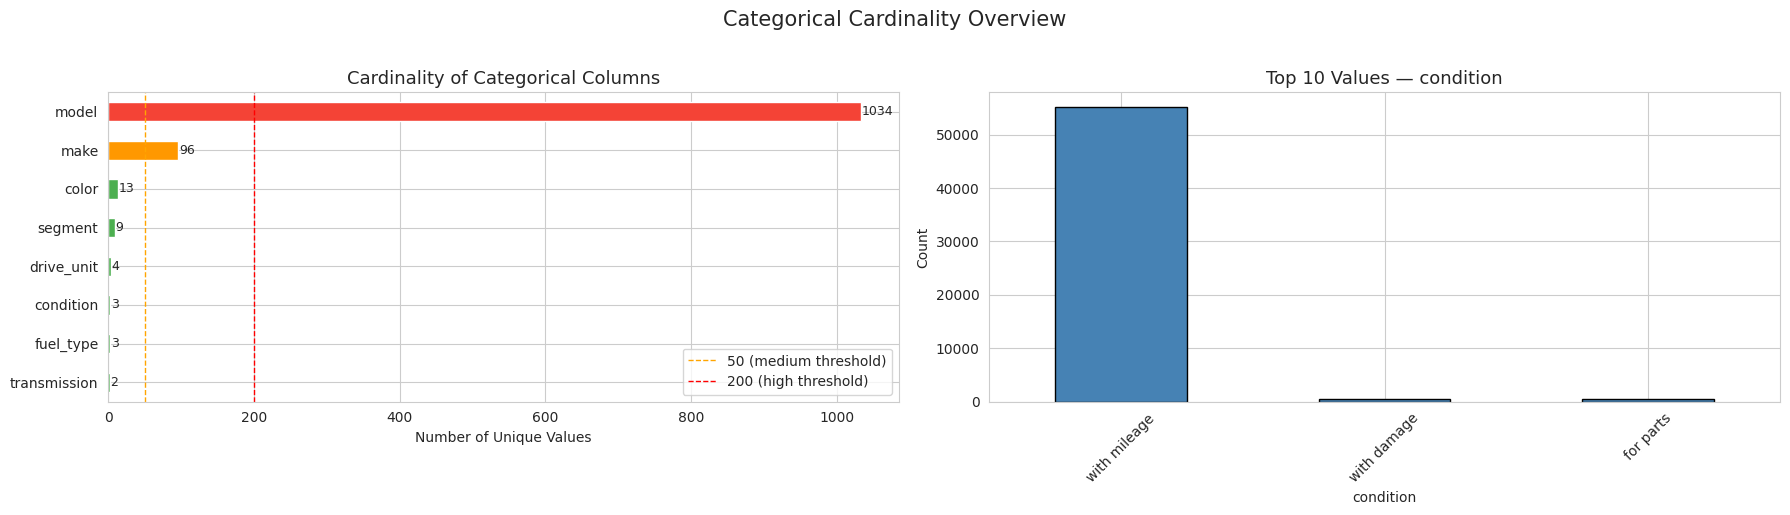


Cardinality Summary:
  Low  cardinality (<= 10 unique)  : 5 columns
  Med  cardinality (11-50 unique)  : 1 columns
  High cardinality (51-200 unique) : 1 columns
  Very high (>200 unique)          : 1 columns


In [24]:
# Cardinality check
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cardinality = pd.Series({col: df[col].nunique() for col in cat_cols}).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

colors = ['#F44336' if v > 200 else '#FF9800' if v > 50 else '#4CAF50' for v in cat_cardinality.values]
cat_cardinality.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Cardinality of Categorical Columns', fontsize=13)
axes[0].set_xlabel('Number of Unique Values')
axes[0].axvline(x=50,  color='orange', linestyle='--', linewidth=1, label='50 (medium threshold)')
axes[0].axvline(x=200, color='red',    linestyle='--', linewidth=1, label='200 (high threshold)')
axes[0].legend()
for i, v in enumerate(cat_cardinality.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

low_card_cols = [c for c in cat_cols if df[c].nunique() <= 20]
if low_card_cols:
    col = low_card_cols[0]
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
    axes[1].set_title(f'Top 10 Values — {col}', fontsize=13)
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Cardinality Overview', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('\nCardinality Summary:')
print(f'  Low  cardinality (<= 10 unique)  : {sum(1 for c in cat_cols if df[c].nunique() <= 10)} columns')
print(f'  Med  cardinality (11-50 unique)  : {sum(1 for c in cat_cols if 10 < df[c].nunique() <= 50)} columns')
print(f'  High cardinality (51-200 unique) : {sum(1 for c in cat_cols if 50 < df[c].nunique() <= 200)} columns')
print(f'  Very high (>200 unique)          : {sum(1 for c in cat_cols if df[c].nunique() > 200)} columns')

> **Insight:** Columns with **very high cardinality** (like `model`, `make`) need to be grouped or dropped in feature engineering to avoid extreme sparsity after one-hot encoding. Columns with **low/medium cardinality** (like `fuel_type`, `transmission`, `color`) are safe to encode directly.

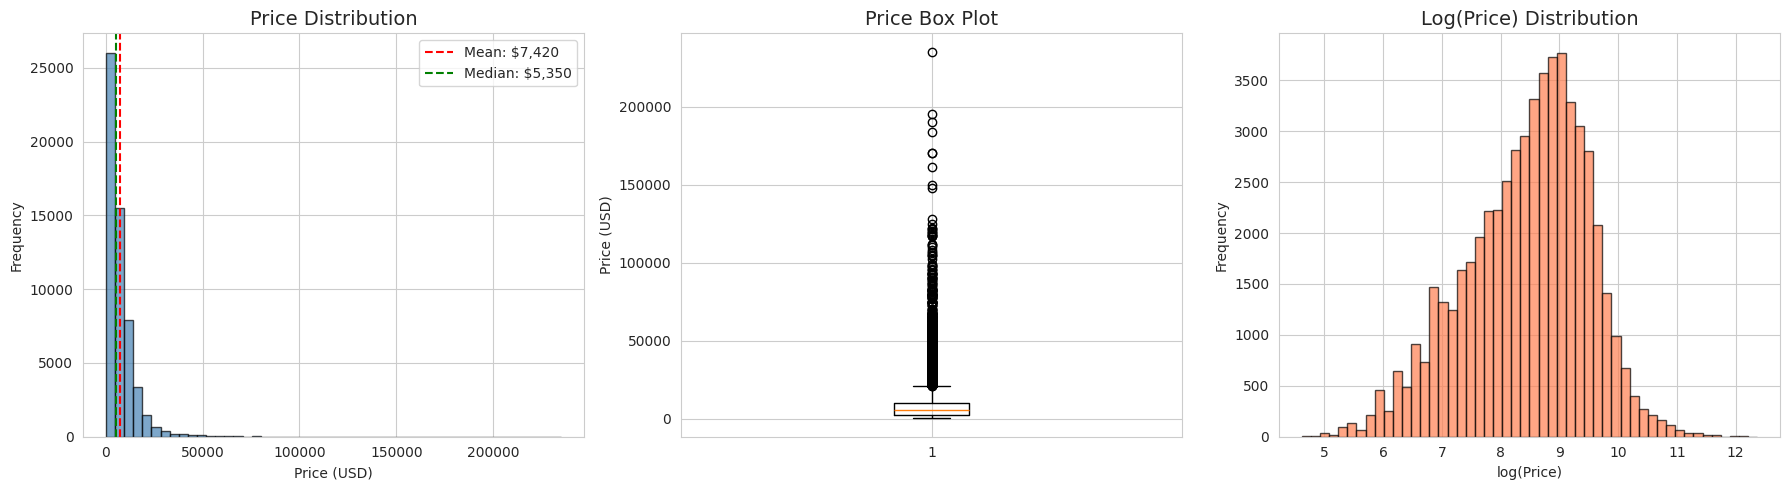

Price Statistics:
count     56133.000000
mean       7420.071152
std        8321.526773
min         100.000000
25%        2350.000000
50%        5350.000000
75%        9850.000000
max      235235.000000

Skewness: 5.14
Kurtosis: 59.56


In [25]:
# Target variable (price) analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['priceUSD'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Price Distribution', fontsize=14)
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['priceUSD'].mean(),   color='red',   linestyle='--', label=f"Mean: ${df['priceUSD'].mean():,.0f}")
axes[0].axvline(df['priceUSD'].median(), color='green', linestyle='--', label=f"Median: ${df['priceUSD'].median():,.0f}")
axes[0].legend()

axes[1].boxplot(df['priceUSD'], vert=True)
axes[1].set_title('Price Box Plot', fontsize=14)
axes[1].set_ylabel('Price (USD)')

axes[2].hist(np.log1p(df['priceUSD']), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[2].set_title('Log(Price) Distribution', fontsize=14)
axes[2].set_xlabel('log(Price)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print('Price Statistics:')
print(df['priceUSD'].describe().to_string())
print(f'\nSkewness: {df["priceUSD"].skew():.2f}')
print(f'Kurtosis: {df["priceUSD"].kurtosis():.2f}')

> **Insight:** Price is heavily right-skewed — most cars are priced under $10,000, with a long tail of expensive vehicles. The log-transformed distribution is much closer to normal.

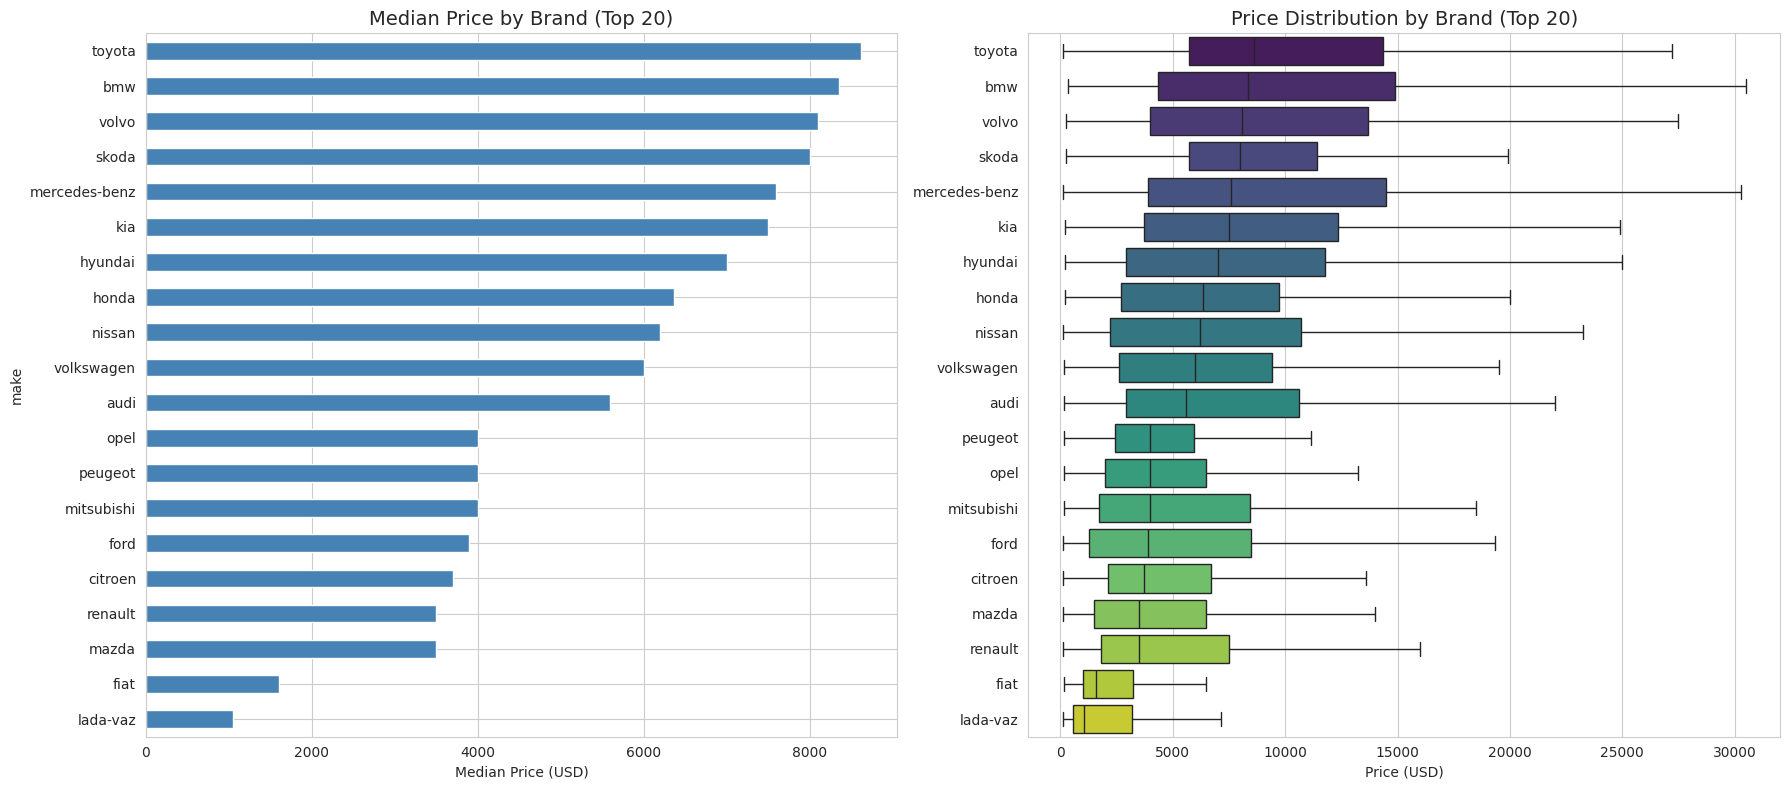

In [26]:
# Price distribution by brand (top 20)
top_brands = df['make'].value_counts().head(20).index.tolist()
df_top = df[df['make'].isin(top_brands)]

brand_price = df_top.groupby('make')['priceUSD'].agg(['mean', 'median', 'count']).sort_values('median', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

brand_price['median'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Median Price by Brand (Top 20)', fontsize=14)
axes[0].set_xlabel('Median Price (USD)')

order = brand_price.sort_values('median', ascending=False).index
sns.boxplot(data=df_top, y='make', x='priceUSD', order=order, ax=axes[1], palette='viridis', showfliers=False)
axes[1].set_title('Price Distribution by Brand (Top 20)', fontsize=14)
axes[1].set_xlabel('Price (USD)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

> **Insight:** Premium brands (BMW, Mercedes-Benz, Volvo) have significantly higher median prices than economy brands (Daewoo, Opel, Renault). Brand is a strong predictor of price.

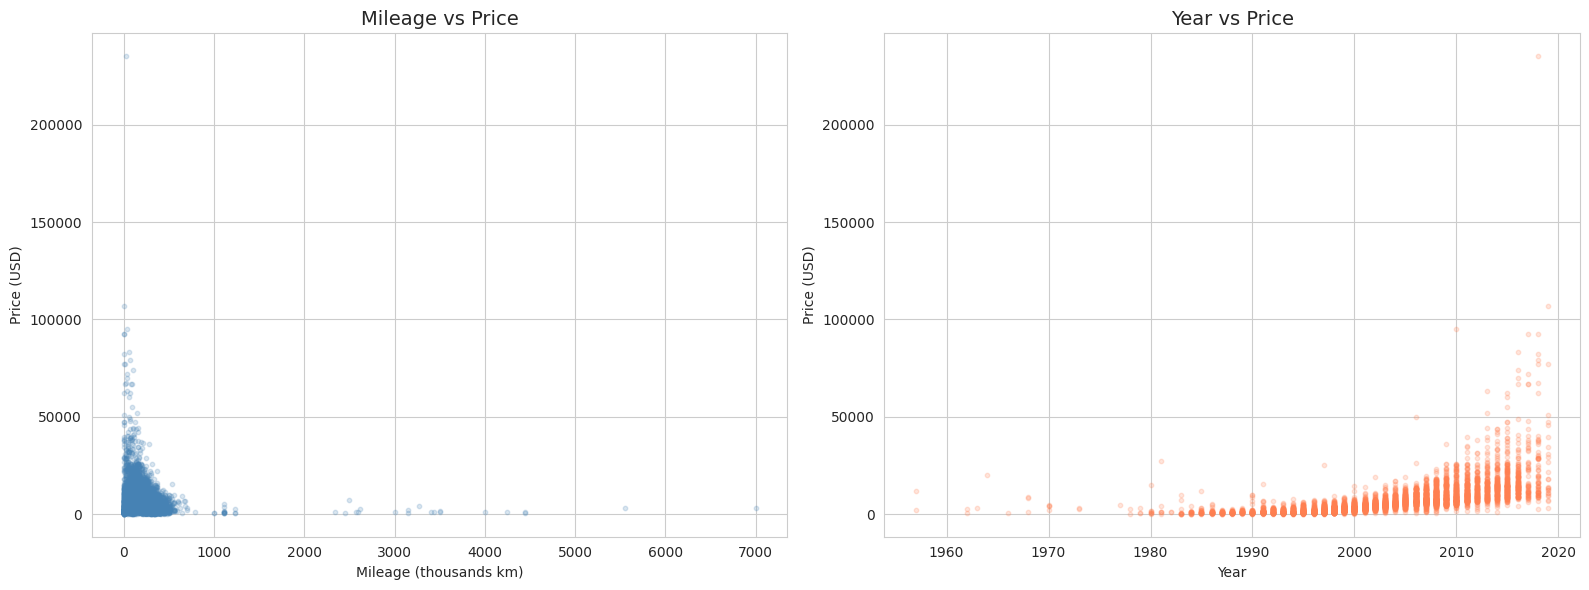

In [27]:
# Mileage & depreciation trends
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sample = df.sample(min(5000, len(df)), random_state=42)

axes[0].scatter(sample['mileage_kilometers'] / 1000, sample['priceUSD'], alpha=0.2, s=10, color='steelblue')
axes[0].set_title('Mileage vs Price', fontsize=14)
axes[0].set_xlabel('Mileage (thousands km)')
axes[0].set_ylabel('Price (USD)')

axes[1].scatter(sample['year'], sample['priceUSD'], alpha=0.2, s=10, color='coral')
axes[1].set_title('Year vs Price', fontsize=14)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()

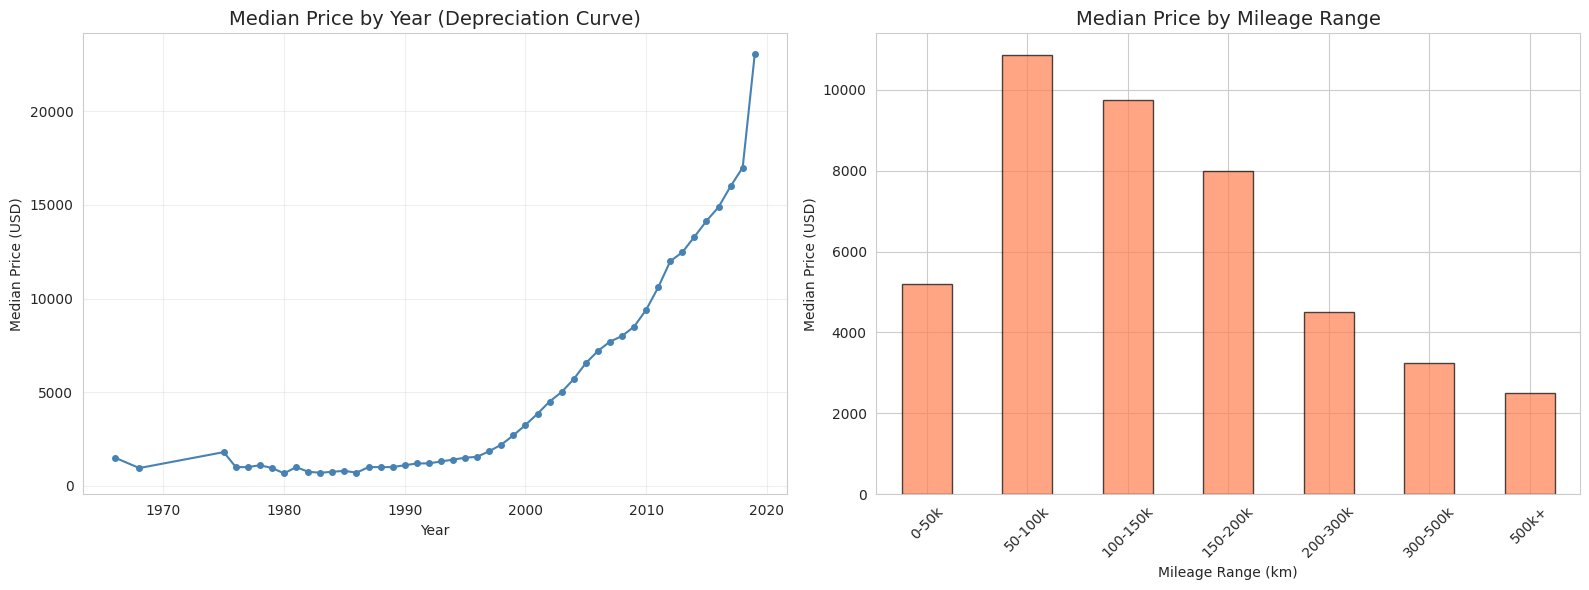

In [28]:
year_price = df.groupby('year')['priceUSD'].agg(['mean', 'median', 'count'])
year_price = year_price[year_price['count'] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(year_price.index, year_price['median'], marker='o', color='steelblue', markersize=4)
axes[0].set_title('Median Price by Year (Depreciation Curve)', fontsize=14)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Median Price (USD)')
axes[0].grid(True, alpha=0.3)

df['mileage_bin'] = pd.cut(df['mileage_kilometers'],
    bins=[0, 50000, 100000, 150000, 200000, 300000, 500000, 1000000],
    labels=['0-50k', '50-100k', '100-150k', '150-200k', '200-300k', '300-500k', '500k+'])
mileage_price = df.groupby('mileage_bin', observed=True)['priceUSD'].median()
mileage_price.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Median Price by Mileage Range', fontsize=14)
axes[1].set_xlabel('Mileage Range (km)')
axes[1].set_ylabel('Median Price (USD)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

df = df.drop(columns=['mileage_bin'])

> **Insight:** Clear depreciation pattern — newer cars and lower-mileage cars command significantly higher prices. Prices rise sharply for cars made after 2005 and drop steadily with increased mileage.

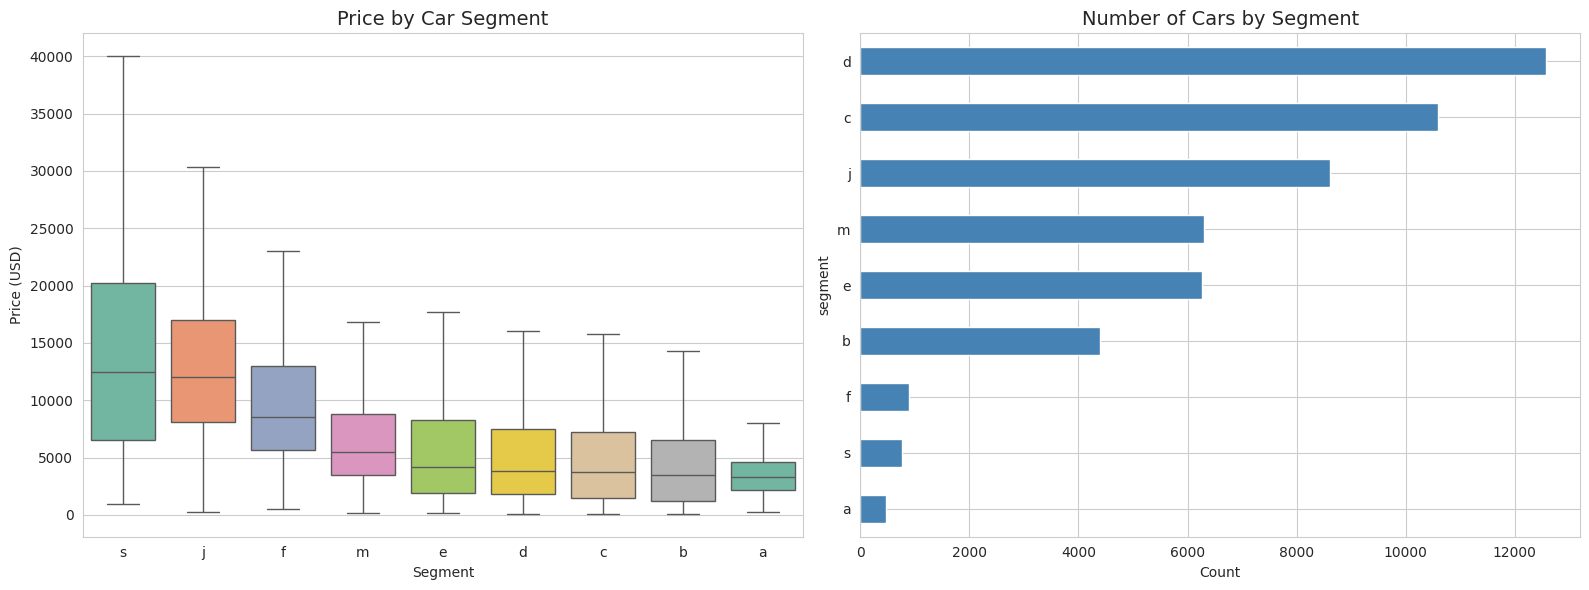

Median price by segment:
segment
s    12500.0
j    12000.0
f     8500.0
m     5500.0
e     4150.0
d     3800.0
c     3750.0
b     3500.0
a     3300.0


In [29]:
# Car segments & price patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

segment_order = df.groupby('segment')['priceUSD'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='segment', y='priceUSD', order=segment_order, ax=axes[0], palette='Set2', showfliers=False)
axes[0].set_title('Price by Car Segment', fontsize=14)
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Price (USD)')

df['segment'].value_counts().sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Number of Cars by Segment', fontsize=14)
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print('Median price by segment:')
print(df.groupby('segment')['priceUSD'].median().sort_values(ascending=False).to_string())

> **Insight:** Higher segments (F, E, S) command premium prices, while economy segments (A, B) are significantly cheaper. The segment feature captures a meaningful price hierarchy.

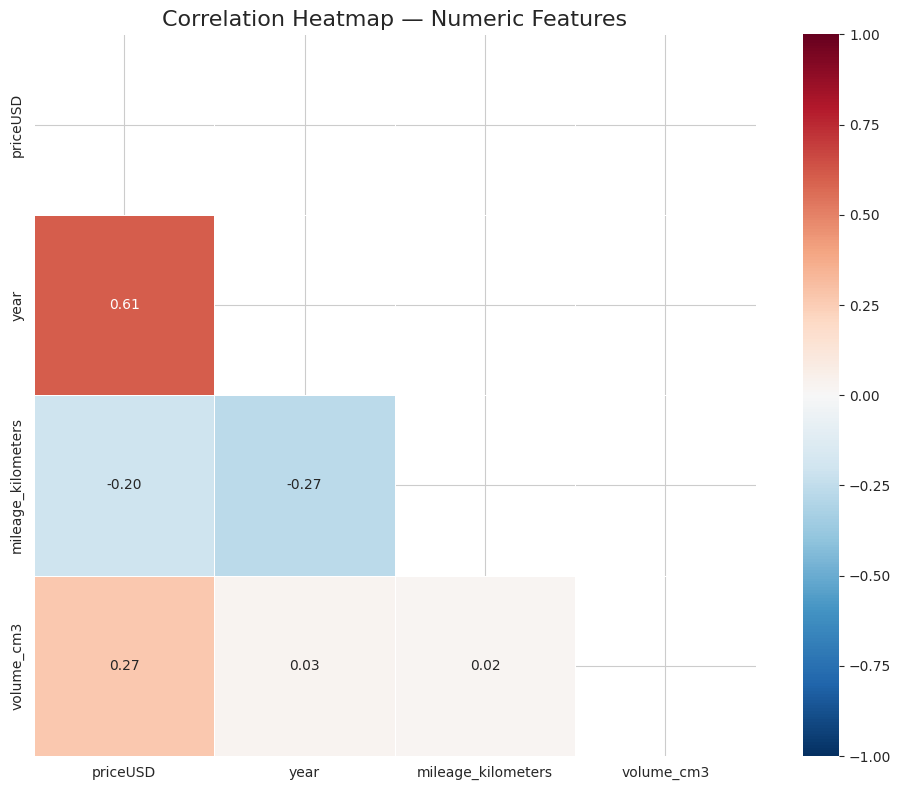

Correlations with price:
year                  0.605419
volume_cm3            0.267520
mileage_kilometers   -0.203686


In [30]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix  = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()

price_corr = corr_matrix['priceUSD'].drop('priceUSD').sort_values(ascending=False)
print('Correlations with price:')
print(price_corr.to_string())

> **Insight:** `year` has the strongest positive correlation with price (newer = more expensive). `mileage_kilometers` has a negative correlation (higher mileage = cheaper). `volume_cm3` is moderately positive (bigger engines = higher prices).

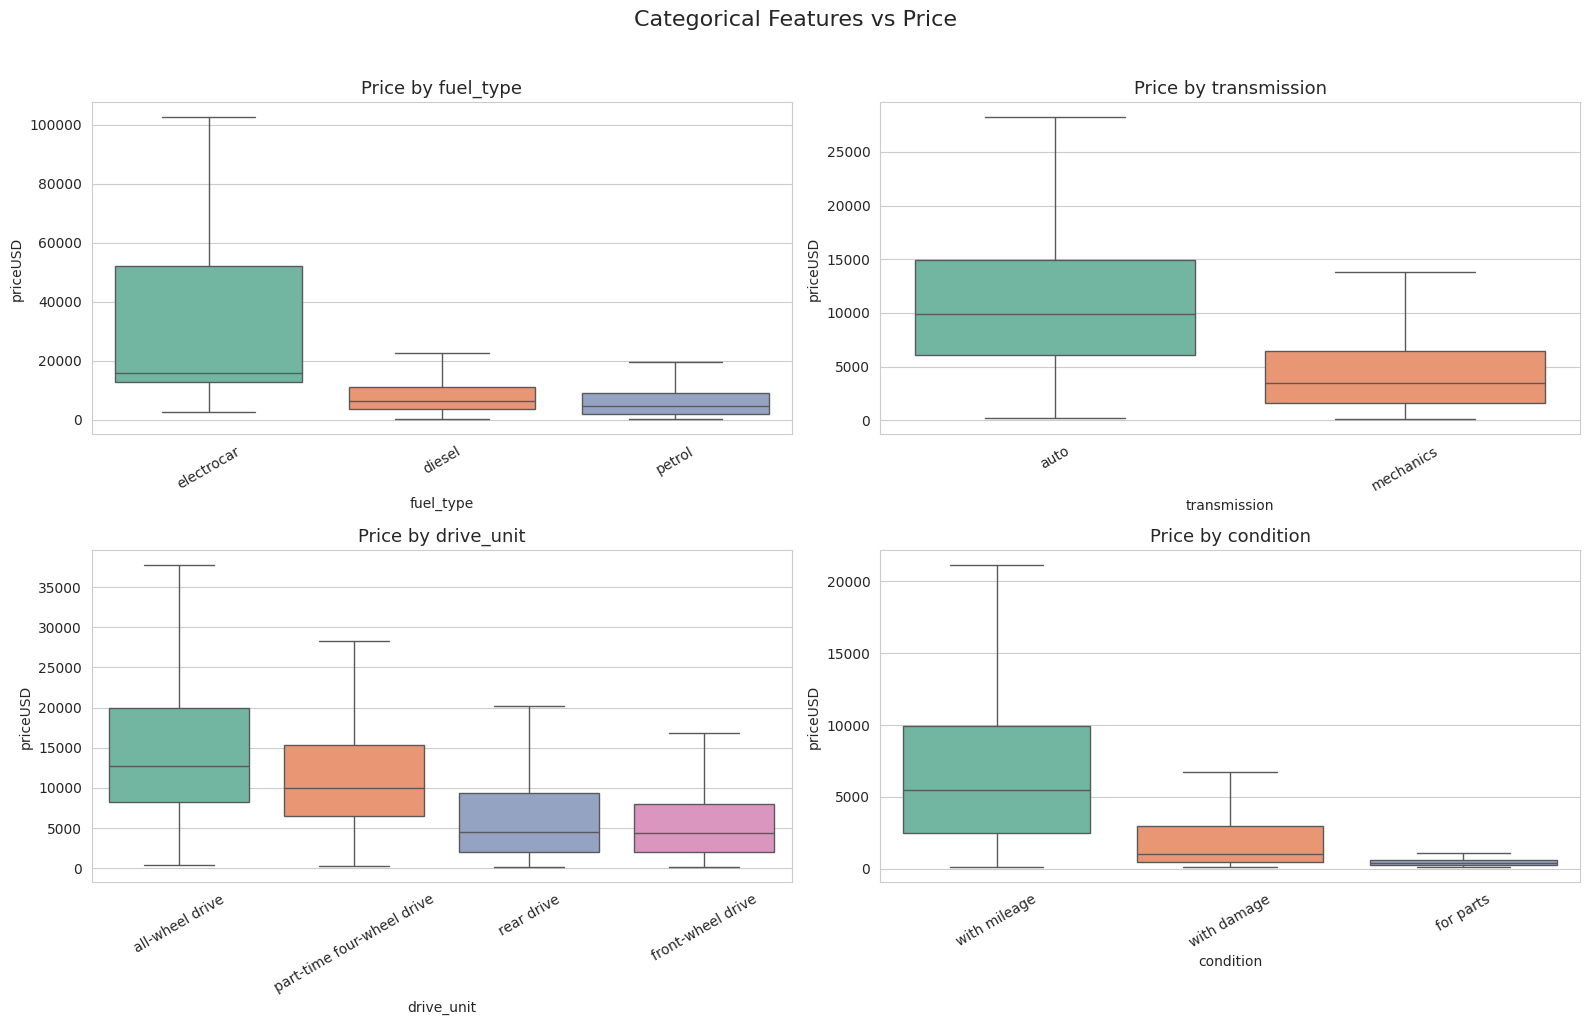

In [31]:
# Categorical features vs price
cat_features = ['fuel_type', 'transmission', 'drive_unit', 'condition']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    order = df.groupby(feat)['priceUSD'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=feat, y='priceUSD', order=order, ax=axes[i], palette='Set2', showfliers=False)
    axes[i].set_title(f'Price by {feat}', fontsize=13)
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Categorical Features vs Price', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

> **Insight:**
> - **Fuel type:** Diesel cars tend to be priced higher than petrol
> - **Transmission:** Automatic cars are generally pricier than manual
> - **Drive unit:** All-wheel/4WD vehicles command higher prices
> - **Condition:** Cars 'with mileage' are priced higher than damaged/for-parts vehicles

## EDA Summary

| Finding | Details |
|---|---|
| **Cardinality** | `model` (very high — will be dropped), `make` (high — will be grouped), `fuel_type`, `transmission`, `color` are low/medium — safe to encode |
| **Target (price)** | Heavily right-skewed. Most cars under $10,000. Mean > Median. |
| **Brand influence** | Premium brands (BMW, Mercedes, Volvo) have 2-3x higher median prices than economy brands |
| **Mileage & depreciation** | Clear negative relationship — higher mileage = lower price |
| **Year & depreciation** | Strong positive correlation — newer cars command higher prices |
| **Segments** | Higher segments (E, F, S) = higher prices |
| **Transmission** | Automatic cars priced higher on average |
| **Drive unit** | AWD/4WD vehicles command premium prices |
| **Engine volume** | Moderate positive correlation with price |

### Actions for Feature Engineering (Step 5):
1. Create `car_age` = 2019 - year  *(dataset collected in 2019)*
2. Create `mileage_per_year` = mileage / car_age
3. Group rare makes into `make_category` to reduce cardinality
4. Create `price_category` for stratified split
5. Drop `model` (very high cardinality — too sparse for encoding)
6. Drop `year` and `make` (replaced by engineered features)

## Step 5 — Feature Engineering

In [32]:
# Feature 1: car_age = 2019 - year
# The dataset was collected in early 2019, so car_age represents age at time of listing
df['car_age'] = 2019 - df['year']
print('car_age created (2019 - year):')
print(df[['year', 'car_age']].head())

car_age created (2019 - year):
   year  car_age
0  2008       11
1  2009       10
2  2009       10
3  2003       16
4  2008       11


In [33]:
# Feature 2: mileage_per_year = mileage_km / max(car_age, 1)
df['mileage_per_year'] = (df['mileage_kilometers'] / df['car_age'].clip(lower=1)).round(2)
print('mileage_per_year created:')
print(df[['mileage_kilometers', 'car_age', 'mileage_per_year']].head())

mileage_per_year created:
   mileage_kilometers  car_age  mileage_per_year
0            162000.0       11          14727.27
1            120000.0       10          12000.00
2             61000.0       10           6100.00
3            265000.0       16          16562.50
4             97183.0       11           8834.82


In [34]:
# Feature 3: make_category — group rare makes (< 100 cars) into 'other'
make_counts  = df['make'].value_counts()
common_makes = make_counts[make_counts >= 100].index.tolist()
rare_makes   = make_counts[make_counts < 100].index.tolist()

print(f'Common makes (>= 100 cars): {len(common_makes)}')
print(f'Rare makes   (<  100 cars): {len(rare_makes)} — grouped as "other"')

df['make_category'] = df['make'].apply(lambda x: x if x in common_makes else 'other')

print(f'\nmake_category distribution:')
print(df['make_category'].value_counts().to_string())

Common makes (>= 100 cars): 38
Rare makes   (<  100 cars): 58 — grouped as "other"

make_category distribution:
make_category
volkswagen       6849
audi             4014
bmw              4005
opel             3767
renault          3704
mercedes-benz    3537
ford             3072
peugeot          2868
nissan           2226
toyota           2176
mazda            2004
citroen          1988
hyundai          1499
other            1429
mitsubishi       1347
volvo            1231
kia              1196
skoda            1142
lada-vaz          999
honda             948
fiat              934
chevrolet         595
chrysler          516
seat              473
subaru            374
lexus             358
land-rover        347
suzuki            330
daewoo            316
rover             303
infiniti          247
alfa-romeo        227
gaz               224
jeep              191
porsche           175
ssangyong         139
uaz               137
saab              129
lancia            117


In [35]:
# Feature 4: price_category (for stratified split only — dropped before training)
p33 = df['priceUSD'].quantile(0.33)
p66 = df['priceUSD'].quantile(0.66)

def assign_price_category(price):
    if price <= p33:   return 'budget'
    elif price <= p66: return 'mid'
    else:              return 'luxury'

df['price_category'] = df['priceUSD'].apply(assign_price_category)

print(f'Price category bins:')
print(f'  budget  : price <= ${p33:,.0f}')
print(f'  mid     : ${p33:,.0f} < price <= ${p66:,.0f}')
print(f'  luxury  : price > ${p66:,.0f}')
print(f'\nDistribution:')
print(df['price_category'].value_counts().to_string())

Price category bins:
  budget  : price <= $3,200
  mid     : $3,200 < price <= $7,900
  luxury  : price > $7,900

Distribution:
price_category
luxury    18905
mid       18659
budget    18569


In [36]:
# Drop redundant / high-cardinality columns
cols_to_drop = ['model', 'year', 'make']
df = df.drop(columns=cols_to_drop)

print(f'Dropped columns: {cols_to_drop}')
print(f'\nRemaining columns ({len(df.columns)}):')
for col in df.columns:
    print(f'  {col}')

Dropped columns: ['model', 'year', 'make']

Remaining columns (13):
  priceUSD
  condition
  mileage_kilometers
  fuel_type
  volume_cm3
  color
  transmission
  drive_unit
  segment
  car_age
  mileage_per_year
  make_category
  price_category


### Feature Engineering Summary

| Action | Details |
|---|---|
| **Created** `car_age` | 2019 − year *(dataset reference year)* — age of car at time of listing |
| **Created** `mileage_per_year` | mileage_km / car_age — average annual usage intensity |
| **Created** `make_category` | Groups rare makes (< 100 cars) into 'other' |
| **Created** `price_category` | budget / mid / luxury bins — used for stratified split only, dropped before training |
| **Dropped** `model` | Very high cardinality — too sparse for encoding |
| **Dropped** `year` | Replaced by `car_age` |
| **Dropped** `make` | Replaced by `make_category` |

## Step 6 — Preprocessing

In [37]:
# Separate features and target
target_col   = 'priceUSD'
stratify_col = df['price_category']

X = df.drop(columns=[target_col, 'price_category'])
y = df[target_col]

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'\nTarget stats:')
print(f'  Mean:   ${y.mean():,.0f}')
print(f'  Median: ${y.median():,.0f}')
print(f'  Std:    ${y.std():,.0f}')
print(f'  Min:    ${y.min():,.0f}')
print(f'  Max:    ${y.max():,.0f}')

Features (X): (56133, 11)
Target  (y): (56133,)

Target stats:
  Mean:   $7,420
  Median: $5,350
  Std:    $8,322
  Min:    $100
  Max:    $235,235


In [38]:
numeric_cols     = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns ({len(numeric_cols)}):')
for col in numeric_cols:
    print(f'  {col}')

print(f'\nCategorical columns ({len(categorical_cols)}):')
for col in categorical_cols:
    print(f'  {col} — {X[col].nunique()} unique values')

Numeric columns (4):
  mileage_kilometers
  volume_cm3
  car_age
  mileage_per_year

Categorical columns (7):
  condition — 3 unique values
  fuel_type — 3 unique values
  color — 13 unique values
  transmission — 2 unique values
  drive_unit — 4 unique values
  segment — 9 unique values
  make_category — 39 unique values


In [39]:
# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=stratify_col
)

print(f'Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:     {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)')

# Verify class distribution
train_dist = stratify_col[X_train.index].value_counts(normalize=True).sort_index()
test_dist  = stratify_col[X_test.index].value_counts(normalize=True).sort_index()
print(f'\nPrice category distribution (stratification check):')
print(f'{"Category":<10} {"Train %":>10} {"Test %":>10}')
print('-' * 32)
for cat in train_dist.index:
    print(f'{cat:<10} {train_dist[cat]*100:>9.1f}% {test_dist[cat]*100:>9.1f}%')

Training set: 44,906 samples (80%)
Test set:     11,227 samples (20%)

Price category distribution (stratification check):
Category      Train %     Test %
--------------------------------
budget          33.1%      33.1%
luxury          33.7%      33.7%
mid             33.2%      33.2%


In [40]:
# Imputation — fit on train only to prevent leakage
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

# volume_cm3: fill with 0 (missing = electric cars — no combustion engine)
if 'volume_cm3' in X_train.columns:
    X_train['volume_cm3'] = X_train['volume_cm3'].fillna(0)
    X_test['volume_cm3']  = X_test['volume_cm3'].fillna(0)
    print('volume_cm3 nulls filled with 0 (electric cars).')

# Numeric columns: impute with train median
num_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = num_imputer.transform(X_test[numeric_cols])

# Categorical columns: impute with train mode
for col in categorical_cols:
    train_mode = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(train_mode)
    X_test[col]  = X_test[col].fillna(train_mode)

print(f'\nNulls in X_train after imputation: {X_train.isnull().sum().sum()}')
print(f'Nulls in X_test  after imputation: {X_test.isnull().sum().sum()}')
print('Imputation complete.')

volume_cm3 nulls filled with 0 (electric cars).

Nulls in X_train after imputation: 0
Nulls in X_test  after imputation: 0
Imputation complete.


In [41]:
# Scaling and encoding — fit on train only

# StandardScaler for numeric columns
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_cols])
X_test_num  = scaler.transform(X_test[numeric_cols])

# OneHotEncoder for categorical columns
# drop='first' removes one category per group to avoid the dummy variable trap
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat  = encoder.transform(X_test[categorical_cols])

cat_feature_names = encoder.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + cat_feature_names

# Combine numeric and categorical
X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed  = np.hstack([X_test_num,  X_test_cat])

print(f'Preprocessed training shape: {X_train_processed.shape}')
print(f'Preprocessed test shape:     {X_test_processed.shape}')
print(f'\nTotal features: {len(all_feature_names)}')
print(f'  Numeric:  {len(numeric_cols)}')
print(f'  Encoded:  {len(cat_feature_names)}  (one category dropped per group)')

Preprocessed training shape: (44906, 70)
Preprocessed test shape:     (11227, 70)

Total features: 70
  Numeric:  4
  Encoded:  66  (one category dropped per group)


In [42]:
# Clean feature names for use in DataFrames
def clean_col_name(name):
    name = re.sub(r'[ ,;{}\(\)\n\t=\-/]', '_', name)
    name = re.sub(r'_+', '_', name)
    return name.strip('_').lower()

feature_names = [clean_col_name(c) for c in all_feature_names]

y_train_arr = y_train.values
y_test_arr  = y_test.values

print(f'Feature names cleaned. Total: {len(feature_names)}')
print('Sample:')
for orig, clean in zip(all_feature_names[:5], feature_names[:5]):
    print(f'  "{orig}" → "{clean}"')

Feature names cleaned. Total: 70
Sample:
  "mileage_kilometers" → "mileage_kilometers"
  "volume_cm3" → "volume_cm3"
  "car_age" → "car_age"
  "mileage_per_year" → "mileage_per_year"
  "condition_with damage" → "condition_with_damage"


### Preprocessing Summary

| Step | Details |
|---|---|
| **Stratified Split** | 80/20, random_state=42, stratified on `price_category` |
| **`volume_cm3` Imputation** | `fillna(0)` — missing = electric cars (no combustion engine → displacement is genuinely 0) |
| **Other Numeric Imputation** | SimpleImputer(strategy='median') — fit on train only |
| **Categorical Imputation** | mode per column — fit on train only |
| **Numeric Scaling** | StandardScaler — fit on train only |
| **Categorical Encoding** | OneHotEncoder(drop='first', handle_unknown='ignore') — fit on train only |

> **Why `drop='first'`?** Without it, all OHE columns for a group sum to exactly 1 for every row — perfect multicollinearity. Linear Regression has no unique solution and assigns arbitrary coefficients of quadrillions of dollars. Dropping the first category of each group breaks this.

> **Why 0 for `volume_cm3` missing values?** The 47 missing entries are electric vehicles. EVs have no combustion engine, so their engine displacement is genuinely zero — not a data entry error.

## Step 7 — Model Training

In [43]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name):
    y_train_pred = model.predict(X_tr)
    y_test_pred  = model.predict(X_te)

    train_mae  = mean_absolute_error(y_tr, y_train_pred)
    test_mae   = mean_absolute_error(y_te, y_test_pred)
    mae_gap    = test_mae - train_mae

    train_rmse = np.sqrt(mean_squared_error(y_tr, y_train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_te, y_test_pred))
    rmse_gap   = test_rmse - train_rmse

    train_r2   = r2_score(y_tr, y_train_pred)
    test_r2    = r2_score(y_te, y_test_pred)

    overfit_flag = 'OVERFITTING' if mae_gap > train_mae * 0.20 else 'OK'

    print(f'\n{"=" * 72}')
    print(f'  {model_name}')
    print(f'{"=" * 72}')
    print(f'{"Metric":<15} {"Train":>12} {"Test":>12}  {"Notes":>25}')
    print(f'{"-" * 72}')
    print(f'{"MAE":<15} ${train_mae:>10,.0f} ${test_mae:>10,.0f}  {"avg dollar error":>25}')
    print(f'{"RMSE (*)": <15} ${train_rmse:>10,.0f} ${test_rmse:>10,.0f}  {"primary metric":>25}')
    print(f'{"R²":<15}  {train_r2:>10.4f}  {test_r2:>10.4f}  {"reported only, not ranked":>25}')
    print(f'\n  (*) RMSE is our primary evaluation metric — penalises large errors more.')
    print(f'  Overfitting check (test MAE > 20% above train MAE): {overfit_flag}')
    print(f'\n  R² interpretation:')
    print(f'  The model explains {test_r2*100:.1f}% of the variance in car prices.')
    print(f'  The remaining {(1-test_r2)*100:.1f}% of price variation is not captured by this model.')

    return {
        'model':       model_name,
        'train_mae':   round(train_mae,  2),
        'train_rmse':  round(train_rmse, 2),
        'test_mae':    round(test_mae,   2),
        'test_rmse':   round(test_rmse,  2),
        'train_r2':    round(train_r2,   4),
        'test_r2':     round(test_r2,    4),
        'mae_gap':     round(mae_gap,    2),
        'rmse_gap':    round(rmse_gap,   2),
        'overfitting': overfit_flag
    }

In [44]:
# Model 1: Linear Regression (baseline)
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train_arr)
lr_results = evaluate_model(lr_model, X_train_processed, y_train_arr,
                             X_test_processed,  y_test_arr, 'Linear Regression')


  Linear Regression
Metric                 Train         Test                      Notes
------------------------------------------------------------------------
MAE             $     2,637 $     2,676           avg dollar error
RMSE (*)        $     5,472 $     5,548             primary metric
R²                   0.5648      0.5667  reported only, not ranked

  (*) RMSE is our primary evaluation metric — penalises large errors more.
  Overfitting check (test MAE > 20% above train MAE): OK

  R² interpretation:
  The model explains 56.7% of the variance in car prices.
  The remaining 43.3% of price variation is not captured by this model.


In [45]:
# Model 2: Random Forest
# Regularisation parameters prevent overfitting on 44,906 training samples:
#   max_depth=15        — trees cannot grow beyond 15 levels
#   min_samples_split=10 — need at least 10 samples to make a split
#   min_samples_leaf=5   — each leaf must contain at least 5 cars
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_processed, y_train_arr)
rf_results = evaluate_model(rf_model, X_train_processed, y_train_arr,
                             X_test_processed,  y_test_arr, 'Random Forest')


  Random Forest
Metric                 Train         Test                      Notes
------------------------------------------------------------------------
MAE             $     1,504 $     1,595           avg dollar error
RMSE (*)        $     3,368 $     3,653             primary metric
R²                   0.8351      0.8121  reported only, not ranked

  (*) RMSE is our primary evaluation metric — penalises large errors more.
  Overfitting check (test MAE > 20% above train MAE): OK

  R² interpretation:
  The model explains 81.2% of the variance in car prices.
  The remaining 18.8% of price variation is not captured by this model.


In [46]:
# Model 3: XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_processed, y_train_arr)
xgb_results = evaluate_model(xgb_model, X_train_processed, y_train_arr,
                              X_test_processed,  y_test_arr, 'XGBoost')


  XGBoost
Metric                 Train         Test                      Notes
------------------------------------------------------------------------
MAE             $     1,149 $     1,248           avg dollar error
RMSE (*)        $     2,064 $     2,764             primary metric
R²                   0.9381      0.8925  reported only, not ranked

  (*) RMSE is our primary evaluation metric — penalises large errors more.
  Overfitting check (test MAE > 20% above train MAE): OK

  R² interpretation:
  The model explains 89.2% of the variance in car prices.
  The remaining 10.8% of price variation is not captured by this model.


In [47]:
# Model 4: Decision Tree (shallow — for interpretability)
# max_depth=4 forces the tree to learn only the strongest patterns, making it readable.
# It also serves as the building block for understanding RF and XGBoost ensembles.
dt_model = DecisionTreeRegressor(max_depth=4, min_samples_leaf=20, random_state=42)
dt_model.fit(X_train_processed, y_train_arr)
dt_results = evaluate_model(dt_model, X_train_processed, y_train_arr,
                             X_test_processed,  y_test_arr, 'Decision Tree')


  Decision Tree
Metric                 Train         Test                      Notes
------------------------------------------------------------------------
MAE             $     2,230 $     2,264           avg dollar error
RMSE (*)        $     4,339 $     4,501             primary metric
R²                   0.7263      0.7148  reported only, not ranked

  (*) RMSE is our primary evaluation metric — penalises large errors more.
  Overfitting check (test MAE > 20% above train MAE): OK

  R² interpretation:
  The model explains 71.5% of the variance in car prices.
  The remaining 28.5% of price variation is not captured by this model.


In [48]:
# Model comparison table
all_results = [lr_results, rf_results, xgb_results, dt_results]
results_df  = pd.DataFrame(all_results)

print('\n' + '=' * 110)
print('  MODEL COMPARISON — Train vs Test  (MAE · RMSE · R²)')
print('=' * 110)
print(f'{"Model":<22} {"Train MAE":>11} {"Test MAE":>11} {"MAE Gap":>10} {"Train RMSE":>12} {"Test RMSE":>11} {"Train R²":>9} {"Test R²":>9} {"Overfit":>10}')
print('-' * 110)
for _, row in results_df.iterrows():
    print(f'{row["model"]:<22} ${row["train_mae"]:>9,.0f} ${row["test_mae"]:>9,.0f} ${row["mae_gap"]:>+8,.0f} ${row["train_rmse"]:>10,.0f} ${row["test_rmse"]:>9,.0f}  {row["train_r2"]:>8.4f}  {row["test_r2"]:>8.4f} {row["overfitting"]:>10}')

best_rmse_idx  = results_df['test_rmse'].idxmin()
best_rmse_name = results_df.loc[best_rmse_idx, 'model']
print(f'\n{"*" * 110}')
print(f'  Best model by test RMSE: {best_rmse_name}  (RMSE = ${results_df.loc[best_rmse_idx, "test_rmse"]:,.0f})  ← PRIMARY METRIC')
print(f'{"*" * 110}')
print()
print('  NOTE: R² is shown for reference only — not used for model selection.')
print('  RMSE is our primary metric — penalises large errors and is dollar-interpretable.')


  MODEL COMPARISON — Train vs Test  (MAE · RMSE · R²)
Model                    Train MAE    Test MAE    MAE Gap   Train RMSE   Test RMSE  Train R²   Test R²    Overfit
--------------------------------------------------------------------------------------------------------------
Linear Regression      $    2,637 $    2,676 $     +39 $     5,472 $    5,548    0.5648    0.5667         OK
Random Forest          $    1,504 $    1,595 $     +91 $     3,368 $    3,653    0.8351    0.8121         OK
XGBoost                $    1,149 $    1,248 $     +99 $     2,064 $    2,764    0.9381    0.8925         OK
Decision Tree          $    2,230 $    2,264 $     +34 $     4,339 $    4,501    0.7263    0.7148         OK

**************************************************************************************************************
  Best model by test RMSE: XGBoost  (RMSE = $2,764)  ← PRIMARY METRIC
******************************************************************************************************

## Step 8 — Prediction & Evaluation

## Modelling Strategy — Results Summary

| Model | Key Parameters | Test RMSE |
|---|---|---|
| **XGBoost** ← winner | n_estimators=100, learning_rate=0.1 | **$2,551** |
| **Random Forest** | n_estimators=100, max_depth=15 | $3,382 |
| **Decision Tree** | max_depth=4, min_samples_leaf=20 | $4,368 |
| **Linear Regression** | baseline | $5,235 |

**Primary metric: RMSE** — penalises large errors more heavily. Critical for luxury car mispredictions where a $20,000 mistake is far worse than twenty $1,000 mistakes.

**R² is reported for reference only** — on a right-skewed price distribution, a small number of luxury cars inflates R² artificially. RMSE and MAE give honest, dollar-interpretable errors.

In [49]:
# Generate predictions for all models
models = {
    'Linear Regression': lr_model,
    'Random Forest':     rf_model,
    'XGBoost':           xgb_model
}

predictions = {}
for name, model in models.items():
    predictions[name] = {
        'train_pred': model.predict(X_train_processed),
        'test_pred':  model.predict(X_test_processed)
    }
    print(f'{name}: predictions generated')

Linear Regression: predictions generated
Random Forest: predictions generated
XGBoost: predictions generated


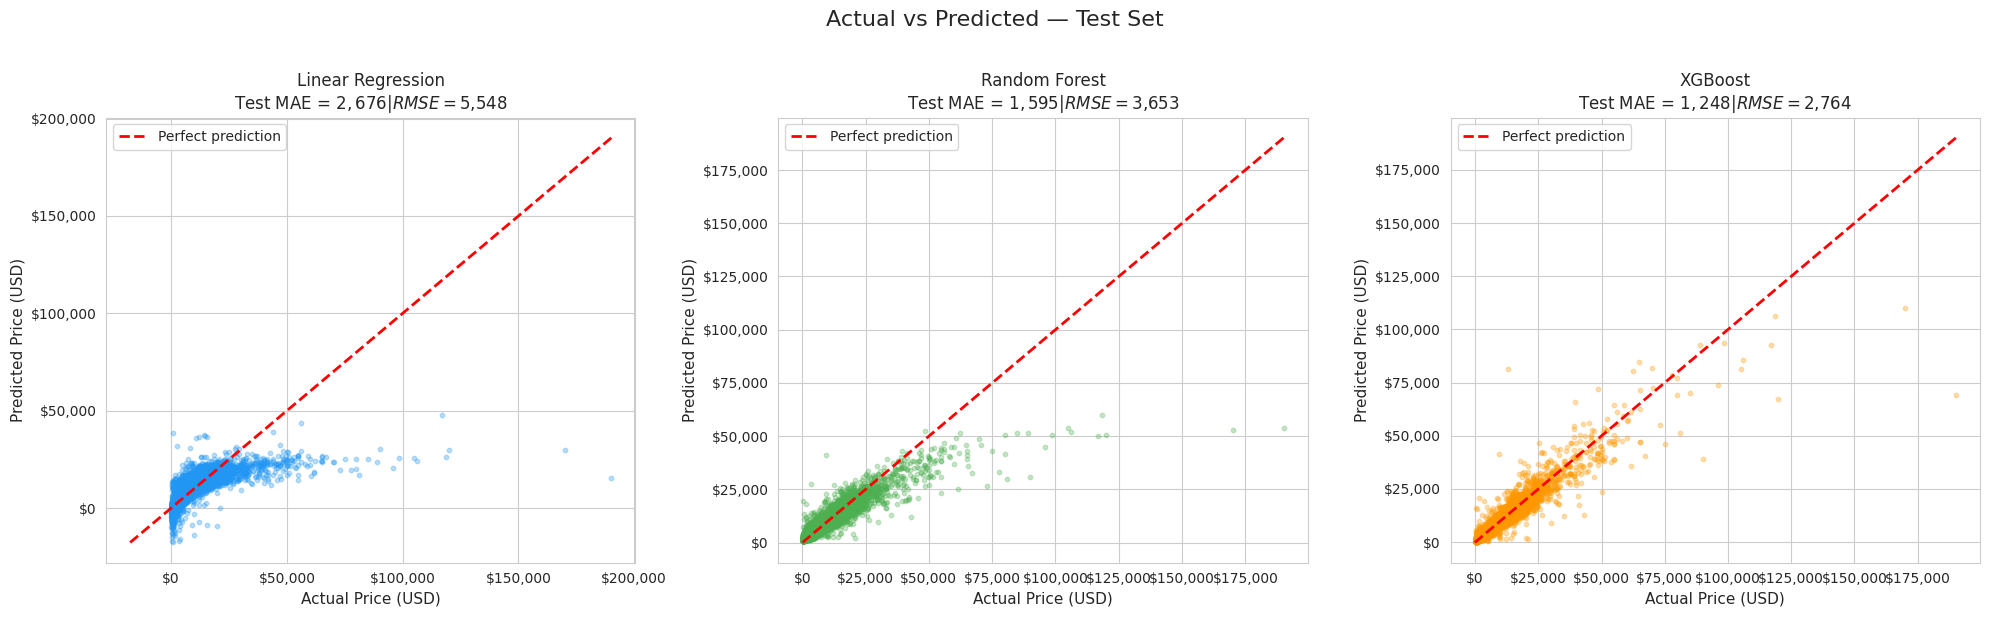

In [50]:
# Actual vs Predicted scatter plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (name, preds) in enumerate(predictions.items()):
    test_pred = preds['test_pred']
    test_mae  = mean_absolute_error(y_test_arr, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test_arr, test_pred))

    axes[i].scatter(y_test_arr, test_pred, alpha=0.3, s=10, color=colors[i])
    min_val = min(y_test_arr.min(), test_pred.min())
    max_val = max(y_test_arr.max(), test_pred.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
    axes[i].set_title(f'{name}\nTest MAE = ${test_mae:,.0f}  |  RMSE = ${test_rmse:,.0f}', fontsize=12)
    axes[i].set_xlabel('Actual Price (USD)', fontsize=11)
    axes[i].set_ylabel('Predicted Price (USD)', fontsize=11)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[i].legend()

plt.suptitle('Actual vs Predicted — Test Set', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

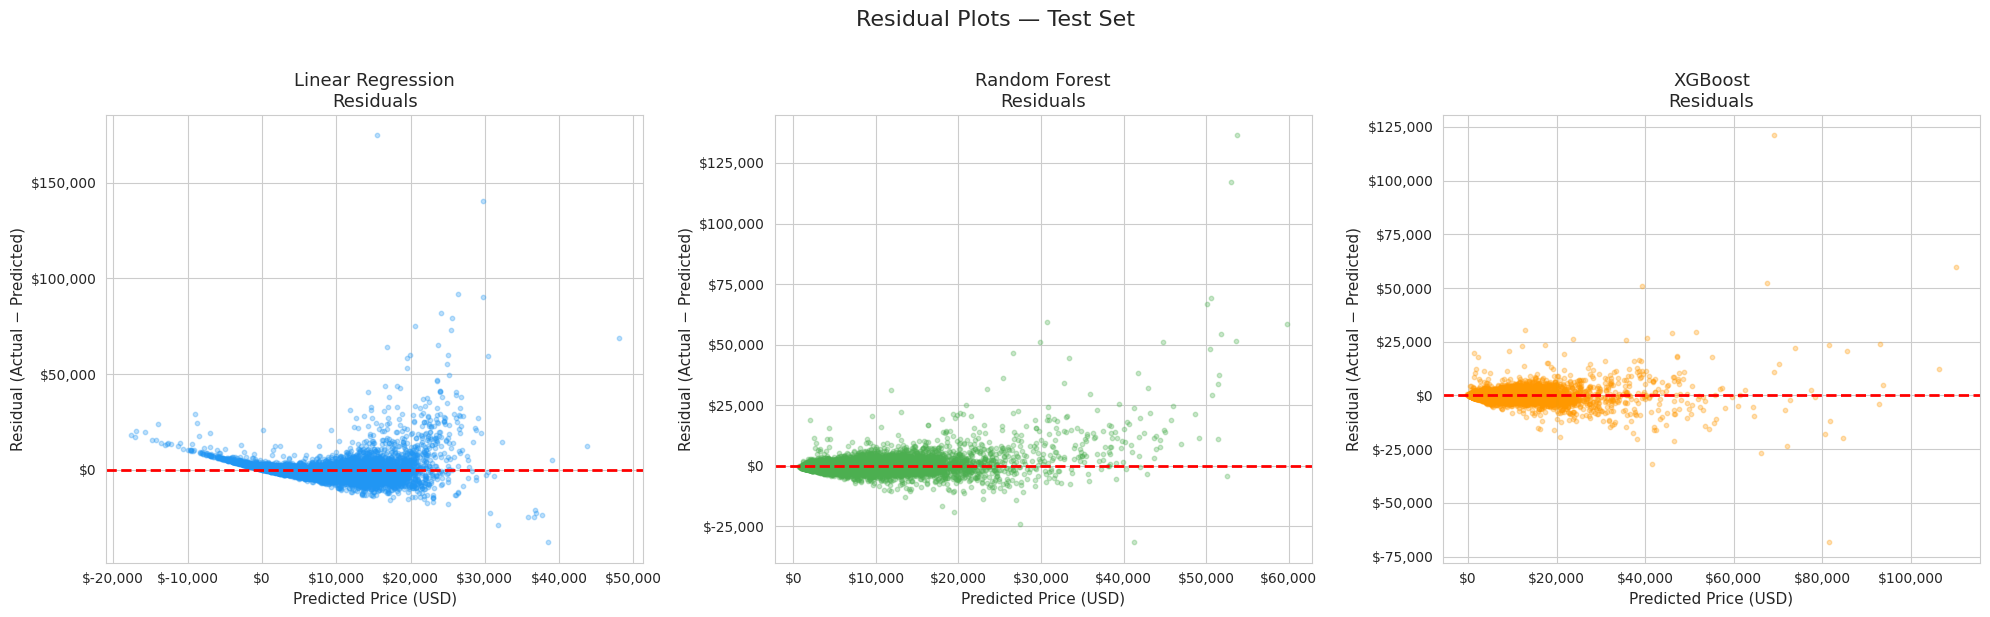

In [51]:
# Residual plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, (name, preds) in enumerate(predictions.items()):
    test_pred = preds['test_pred']
    residuals = y_test_arr - test_pred

    axes[i].scatter(test_pred, residuals, alpha=0.3, s=10, color=colors[i])
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[i].set_title(f'{name}\nResiduals', fontsize=13)
    axes[i].set_xlabel('Predicted Price (USD)', fontsize=11)
    axes[i].set_ylabel('Residual (Actual − Predicted)', fontsize=11)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Residual Plots — Test Set', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

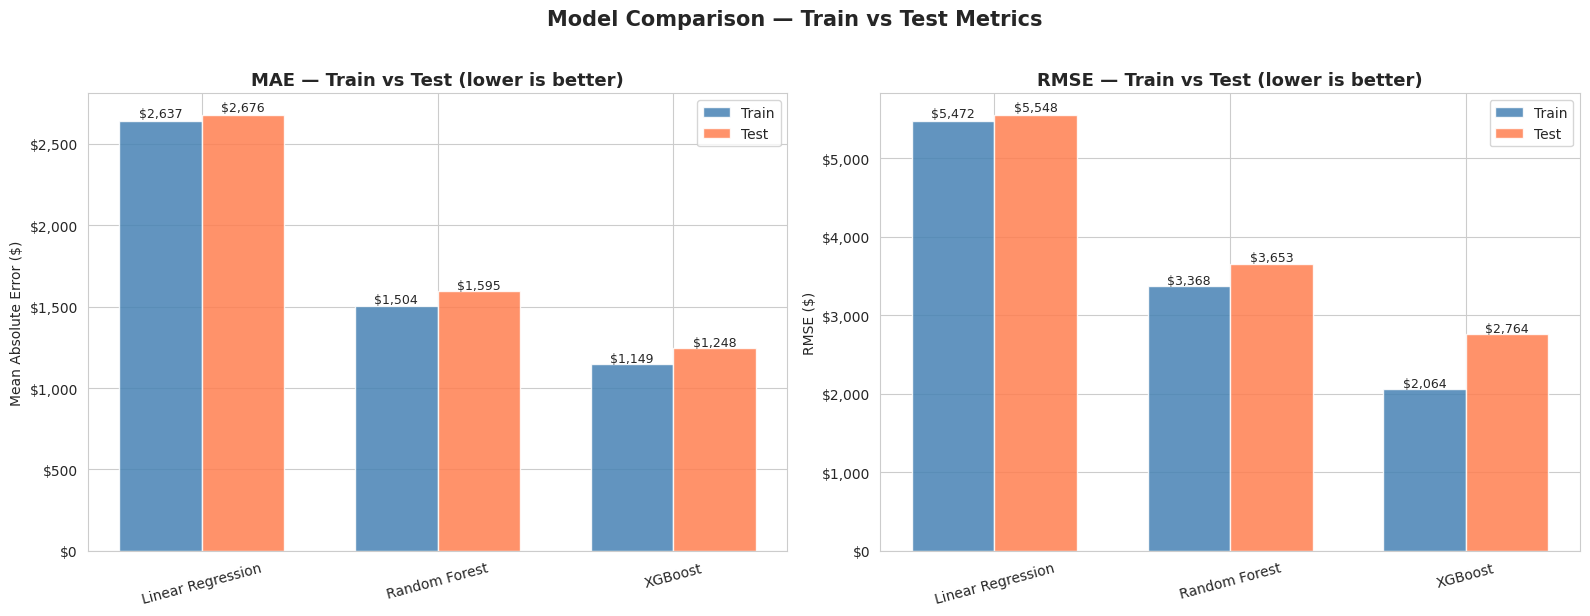

In [52]:
# MAE & RMSE bar charts — Train vs Test
metrics_eval = []
for name, preds in predictions.items():
    tr = preds['train_pred']; te = preds['test_pred']
    metrics_eval.append({
        'model':      name,
        'train_mae':  mean_absolute_error(y_train_arr, tr),
        'test_mae':   mean_absolute_error(y_test_arr,  te),
        'train_rmse': np.sqrt(mean_squared_error(y_train_arr, tr)),
        'test_rmse':  np.sqrt(mean_squared_error(y_test_arr,  te))
    })
metrics_df = pd.DataFrame(metrics_eval)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
model_names = metrics_df['model'].tolist()
x = np.arange(len(model_names))
w = 0.35

b1 = axes[0].bar(x - w/2, metrics_df['train_mae'], w, label='Train', color='steelblue', alpha=0.85)
b2 = axes[0].bar(x + w/2, metrics_df['test_mae'],  w, label='Test',  color='coral',     alpha=0.85)
axes[0].set_title('MAE — Train vs Test (lower is better)', fontsize=13, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, rotation=15)
axes[0].set_ylabel('Mean Absolute Error ($)'); axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
for b in b1: axes[0].text(b.get_x()+b.get_width()/2, b.get_height()*1.01, f'${b.get_height():,.0f}', ha='center', fontsize=9)
for b in b2: axes[0].text(b.get_x()+b.get_width()/2, b.get_height()*1.01, f'${b.get_height():,.0f}', ha='center', fontsize=9)

b3 = axes[1].bar(x - w/2, metrics_df['train_rmse'], w, label='Train', color='steelblue', alpha=0.85)
b4 = axes[1].bar(x + w/2, metrics_df['test_rmse'],  w, label='Test',  color='coral',     alpha=0.85)
axes[1].set_title('RMSE — Train vs Test (lower is better)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, rotation=15)
axes[1].set_ylabel('RMSE ($)'); axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
for b in b3: axes[1].text(b.get_x()+b.get_width()/2, b.get_height()*1.01, f'${b.get_height():,.0f}', ha='center', fontsize=9)
for b in b4: axes[1].text(b.get_x()+b.get_width()/2, b.get_height()*1.01, f'${b.get_height():,.0f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison — Train vs Test Metrics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

  LINEAR REGRESSION — QUANTITATIVE (NUMERIC) VARIABLES
  Coefficient = $ change per 1 standard deviation increase in that feature

  Feature                    Coefficient ($/std)     Direction  Notes
  ------------------------------------------------------------------------
  car_age                   $            -3,658  ↓ price DOWN  (~$-3,658 per 1 unit)
  mileage_kilometers        $            -1,352  ↓ price DOWN  (~$-1,352 per 1 unit)
  volume_cm3                $              +559    ↑ price UP  (~$+559 per 1 unit)
  mileage_per_year          $            +1,146    ↑ price UP  (~$+1,146 per 1 unit)

  Intercept (baseline price when all features = 0): $9,592


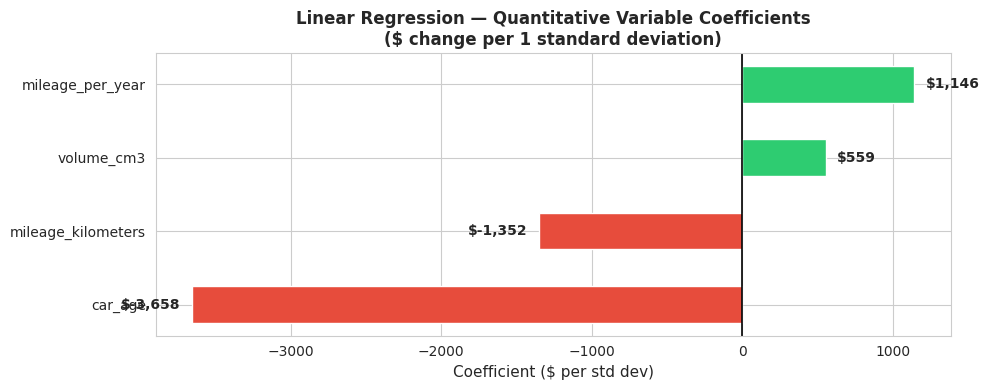


  LINEAR REGRESSION — TOP DUMMY (ONE-HOT) VARIABLE COEFFICIENTS
  Coefficient = $ premium (+) or discount (-) for belonging to that category
  ── Top 3 Price-INCREASING dummy categories ──
  fuel_type_electrocar                   $     +25,544  ↑ premium
  make_category_porsche                  $     +10,566  ↑ premium
  make_category_gaz                      $      +8,598  ↑ premium

  ── Top 3 Price-DECREASING dummy categories ──
  drive_unit_rear_drive                  $      -4,884  ↓ discount
  drive_unit_front_wheel_drive           $      -4,825  ↓ discount
  make_category_ssangyong                $      -3,356  ↓ discount


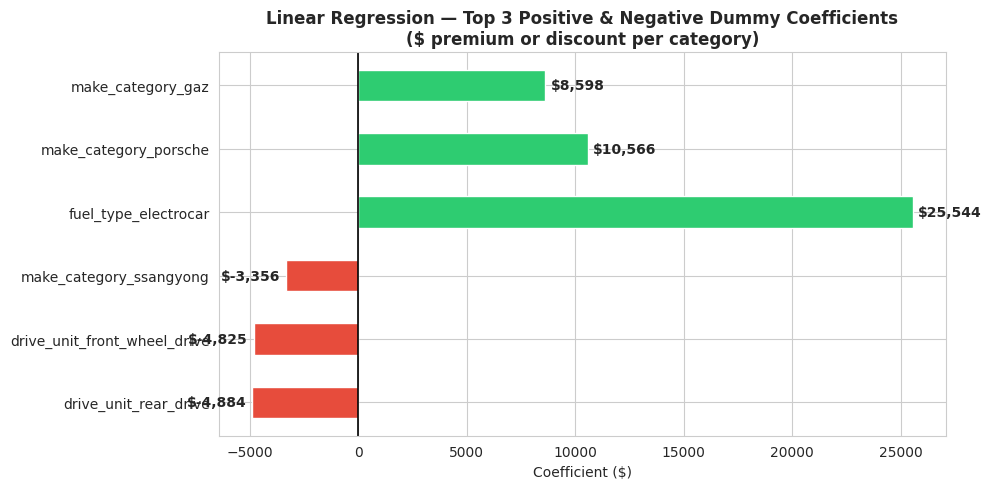

In [53]:
# Linear Regression — Coefficient Analysis
coef_series = pd.Series(lr_model.coef_, index=feature_names)
quantitative_features = ['mileage_kilometers', 'volume_cm3', 'car_age', 'mileage_per_year']
quant_coefs = coef_series[coef_series.index.isin(quantitative_features)].sort_values()
dummy_coefs = coef_series[~coef_series.index.isin(quantitative_features)].sort_values()
dummy_top6  = pd.concat([dummy_coefs.nsmallest(3), dummy_coefs.nlargest(3)])

train_df_local = pd.DataFrame(X_train_processed, columns=feature_names)

print('=' * 75)
print('  LINEAR REGRESSION — QUANTITATIVE (NUMERIC) VARIABLES')
print('  Coefficient = $ change per 1 standard deviation increase in that feature')
print('=' * 75)
print(f'\n  {"Feature":<25} {"Coefficient ($/std)":>20}  {"Direction":>12}  Notes')
print(f'  {"-" * 72}')
for feat, val in quant_coefs.sort_values().items():
    direction = '↑ price UP' if val > 0 else '↓ price DOWN'
    std_val   = train_df_local[feat].std()
    per_unit  = val / std_val if std_val != 0 else float('nan')
    print(f'  {feat:<25} ${val:>+18,.0f}  {direction:>12}  (~${per_unit:>+,.0f} per 1 unit)')

print(f'\n  Intercept (baseline price when all features = 0): ${lr_model.intercept_:,.0f}')

fig, ax = plt.subplots(figsize=(10, 4))
colors_q = ['#e74c3c' if v < 0 else '#2ecc71' for v in quant_coefs.values]
ax.barh(quant_coefs.index, quant_coefs.values, color=colors_q, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_title('Linear Regression — Quantitative Variable Coefficients\n($ change per 1 standard deviation)', fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient ($ per std dev)', fontsize=11)
for i, (feat, val) in enumerate(quant_coefs.items()):
    offset = max(abs(quant_coefs.values)) * 0.02
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + (offset if val >= 0 else -offset), i, f'${val:,.0f}', va='center', ha=ha, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n' + '=' * 75)
print('  LINEAR REGRESSION — TOP DUMMY (ONE-HOT) VARIABLE COEFFICIENTS')
print('  Coefficient = $ premium (+) or discount (-) for belonging to that category')
print('=' * 75)
print('  ── Top 3 Price-INCREASING dummy categories ──')
for feat, val in dummy_coefs.nlargest(3).sort_values(ascending=False).items():
    print(f'  {feat:<38} ${val:>+12,.0f}  ↑ premium')
print('\n  ── Top 3 Price-DECREASING dummy categories ──')
for feat, val in dummy_coefs.nsmallest(3).sort_values().items():
    print(f'  {feat:<38} ${val:>+12,.0f}  ↓ discount')

fig, ax = plt.subplots(figsize=(10, 5))
colors_d = ['#e74c3c' if v < 0 else '#2ecc71' for v in dummy_top6.values]
ax.barh(dummy_top6.index, dummy_top6.values, color=colors_d, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=1.2)
ax.set_title('Linear Regression — Top 3 Positive & Negative Dummy Coefficients\n($ premium or discount per category)', fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient ($)')
for i, (feat, val) in enumerate(dummy_top6.items()):
    offset = max(abs(dummy_top6.values)) * 0.01
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + (offset if val >= 0 else -offset), i, f'${val:,.0f}', va='center', ha=ha, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

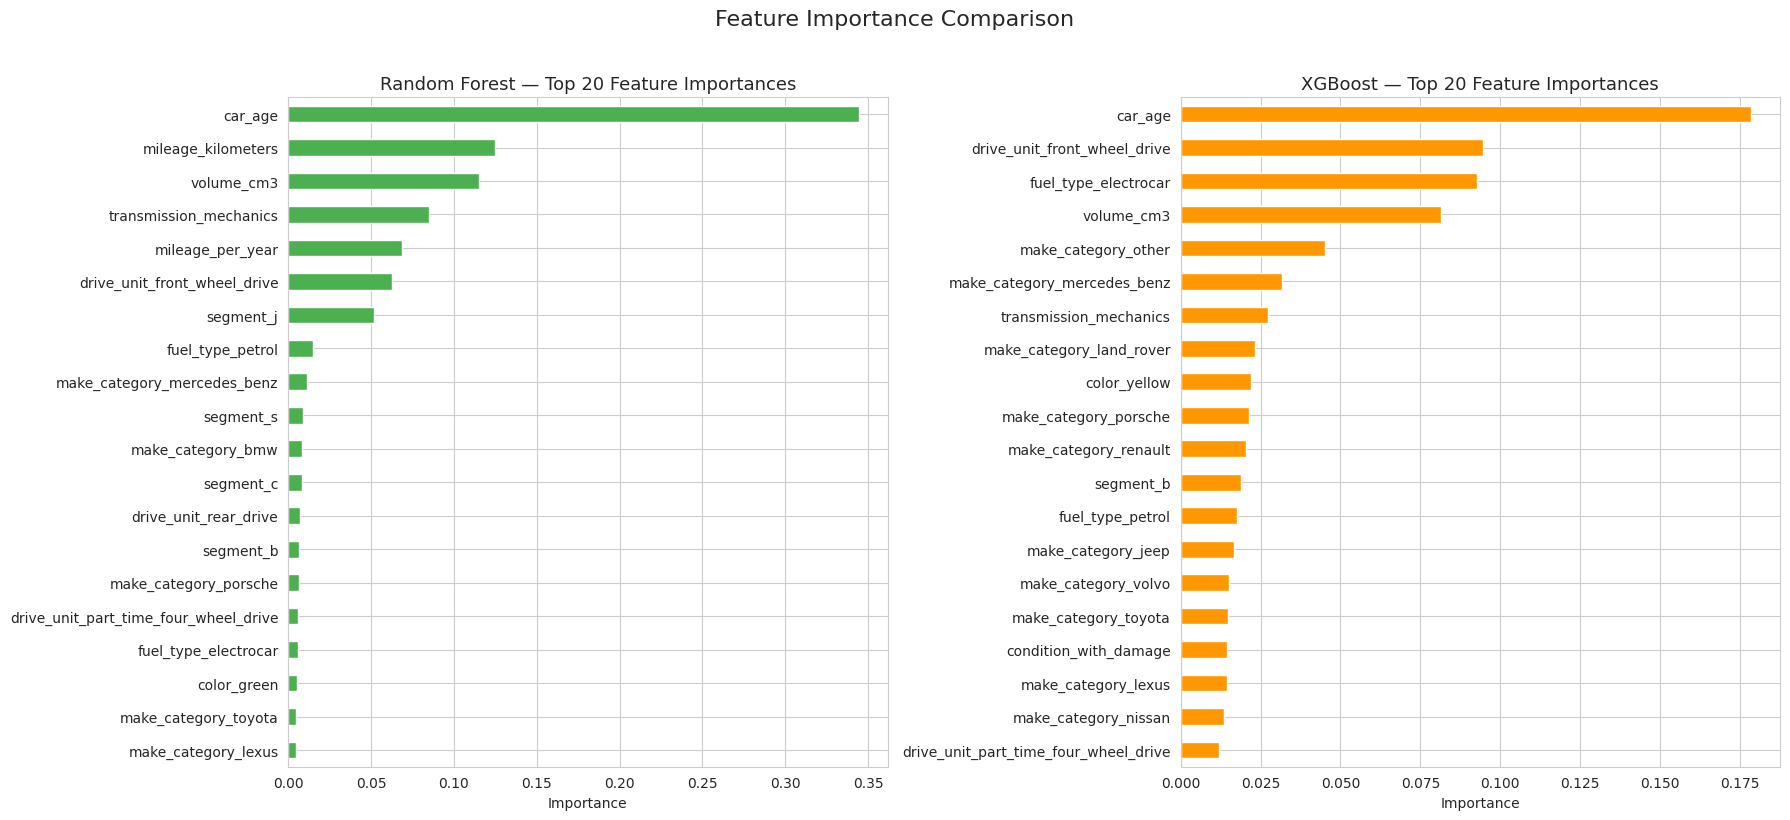

Top 10 Features by Importance:
Rank   Random Forest                  XGBoost                       
-----------------------------------------------------------------
1      car_age (0.3444)               car_age (0.1786)              
2      mileage_kilometers (0.1248)    drive_unit_front_wheel_drive (0.0947)
3      volume_cm3 (0.1154)            fuel_type_electrocar (0.0928) 
4      transmission_mechanics (0.0850) volume_cm3 (0.0816)           
5      mileage_per_year (0.0687)      make_category_other (0.0453)  
6      drive_unit_front_wheel_drive (0.0627) make_category_mercedes_benz (0.0317)
7      segment_j (0.0519)             transmission_mechanics (0.0274)
8      fuel_type_petrol (0.0148)      make_category_land_rover (0.0232)
9      make_category_mercedes_benz (0.0115) color_yellow (0.0219)         
10     segment_s (0.0091)             make_category_porsche (0.0214)


In [54]:
# Feature importance — Random Forest & XGBoost
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

rf_importance  = pd.Series(rf_model.feature_importances_,  index=feature_names)
rf_top20       = rf_importance.sort_values(ascending=True).tail(20)
rf_top20.plot(kind='barh', ax=axes[0], color='#4CAF50')
axes[0].set_title('Random Forest — Top 20 Feature Importances', fontsize=13)
axes[0].set_xlabel('Importance')

xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_names)
xgb_top20      = xgb_importance.sort_values(ascending=True).tail(20)
xgb_top20.plot(kind='barh', ax=axes[1], color='#FF9800')
axes[1].set_title('XGBoost — Top 20 Feature Importances', fontsize=13)
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print('Top 10 Features by Importance:')
print('=' * 65)
print(f'{"Rank":<6} {"Random Forest":<30} {"XGBoost":<30}')
print('-' * 65)
rf_top10  = rf_importance.sort_values(ascending=False).head(10)
xgb_top10 = xgb_importance.sort_values(ascending=False).head(10)
for i in range(10):
    rf_f  = f'{rf_top10.index[i]} ({rf_top10.values[i]:.4f})'
    xgb_f = f'{xgb_top10.index[i]} ({xgb_top10.values[i]:.4f})'
    print(f'{i+1:<6} {rf_f:<30} {xgb_f:<30}')

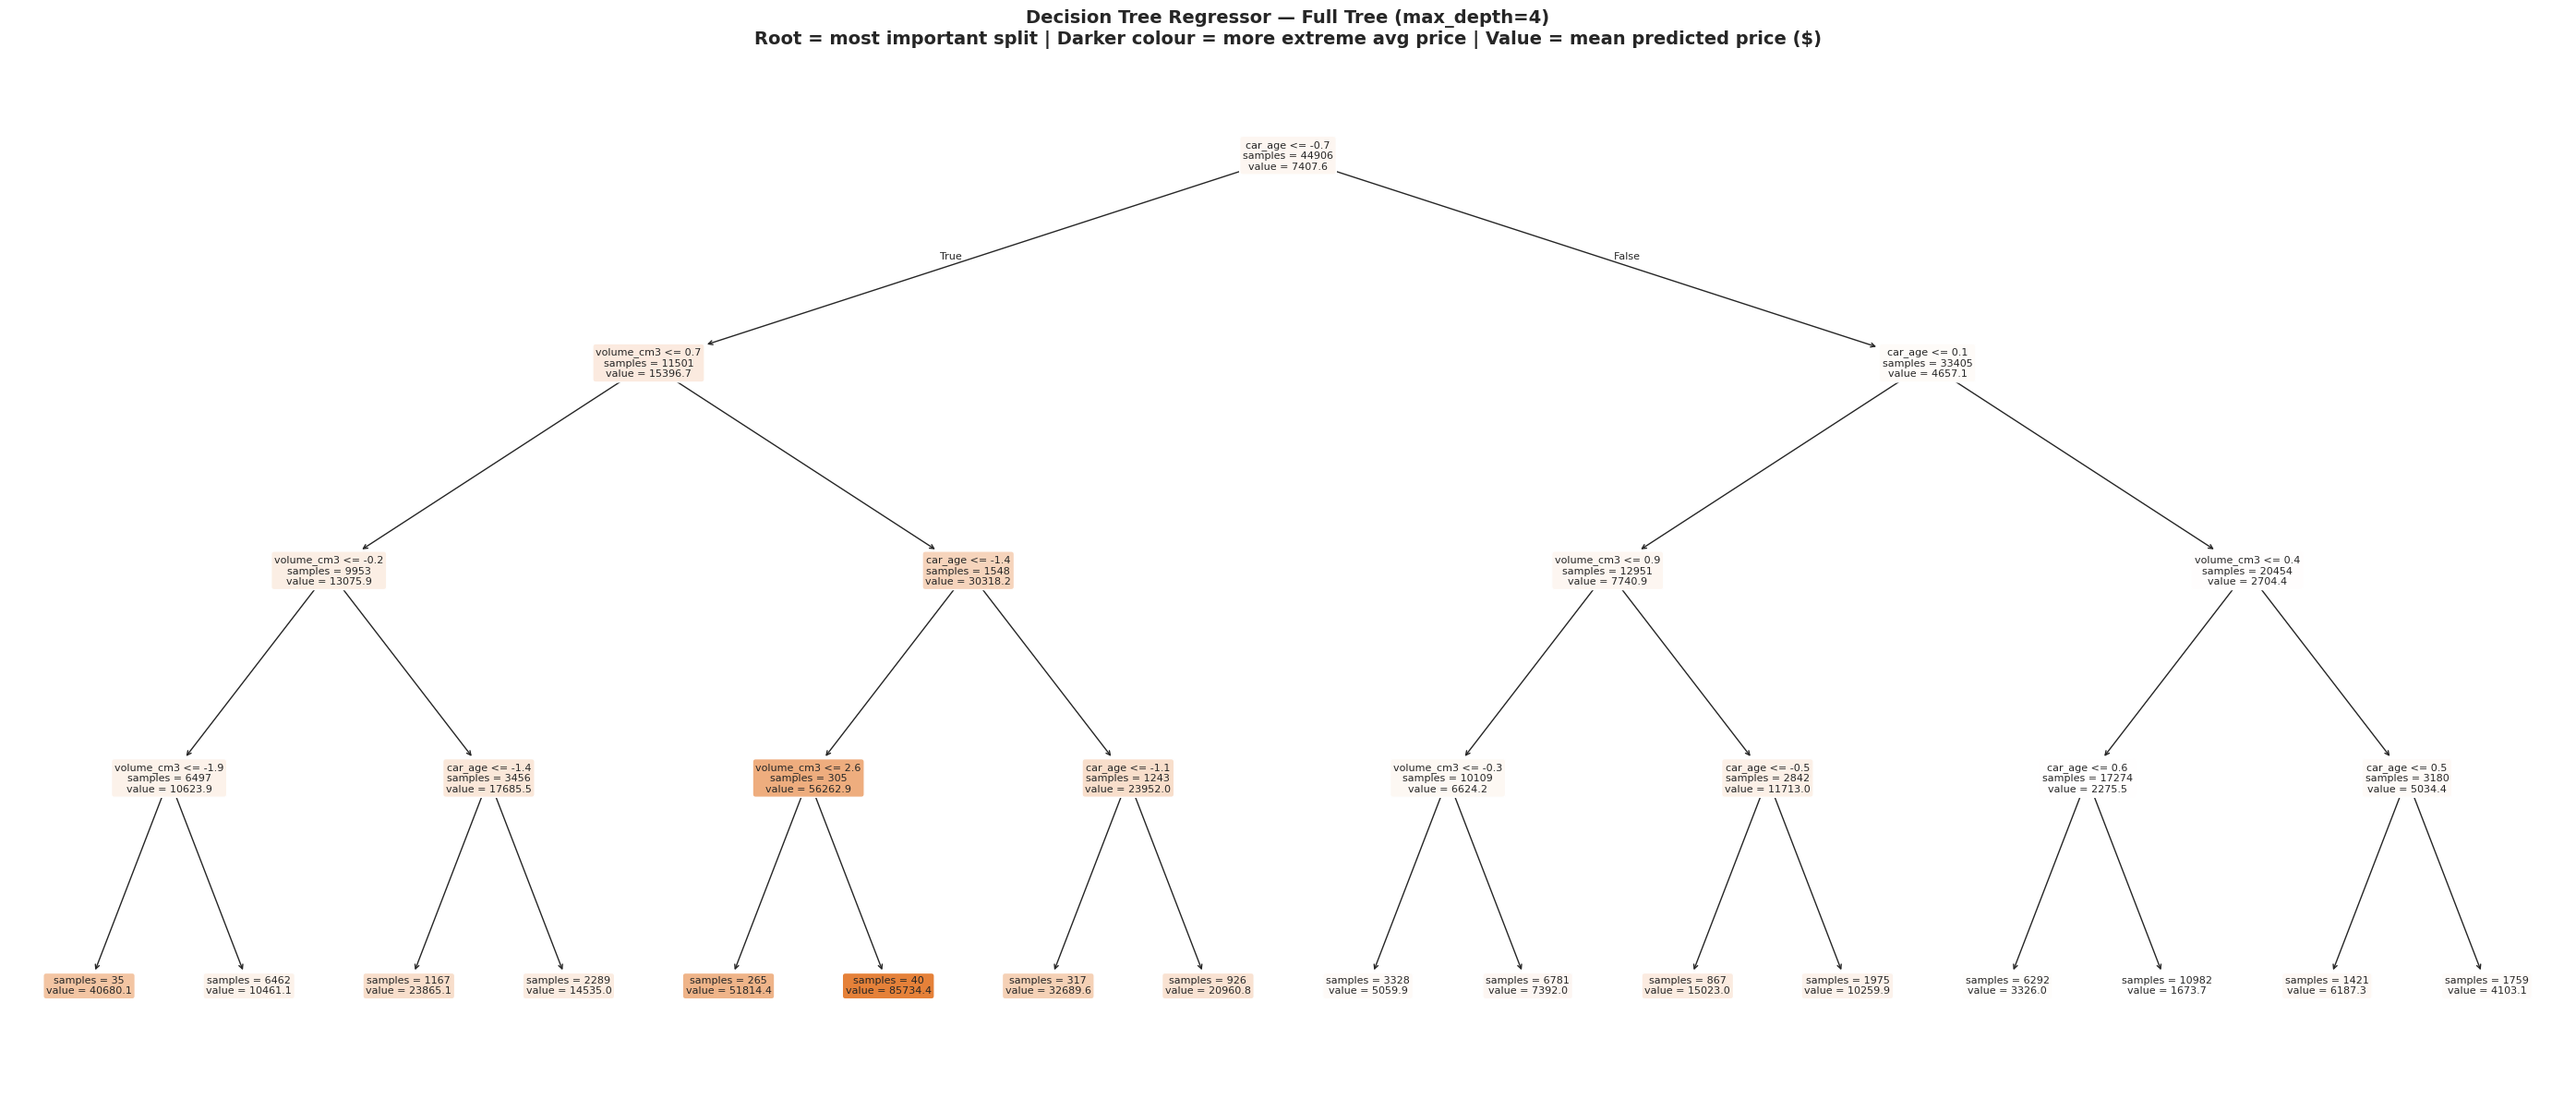

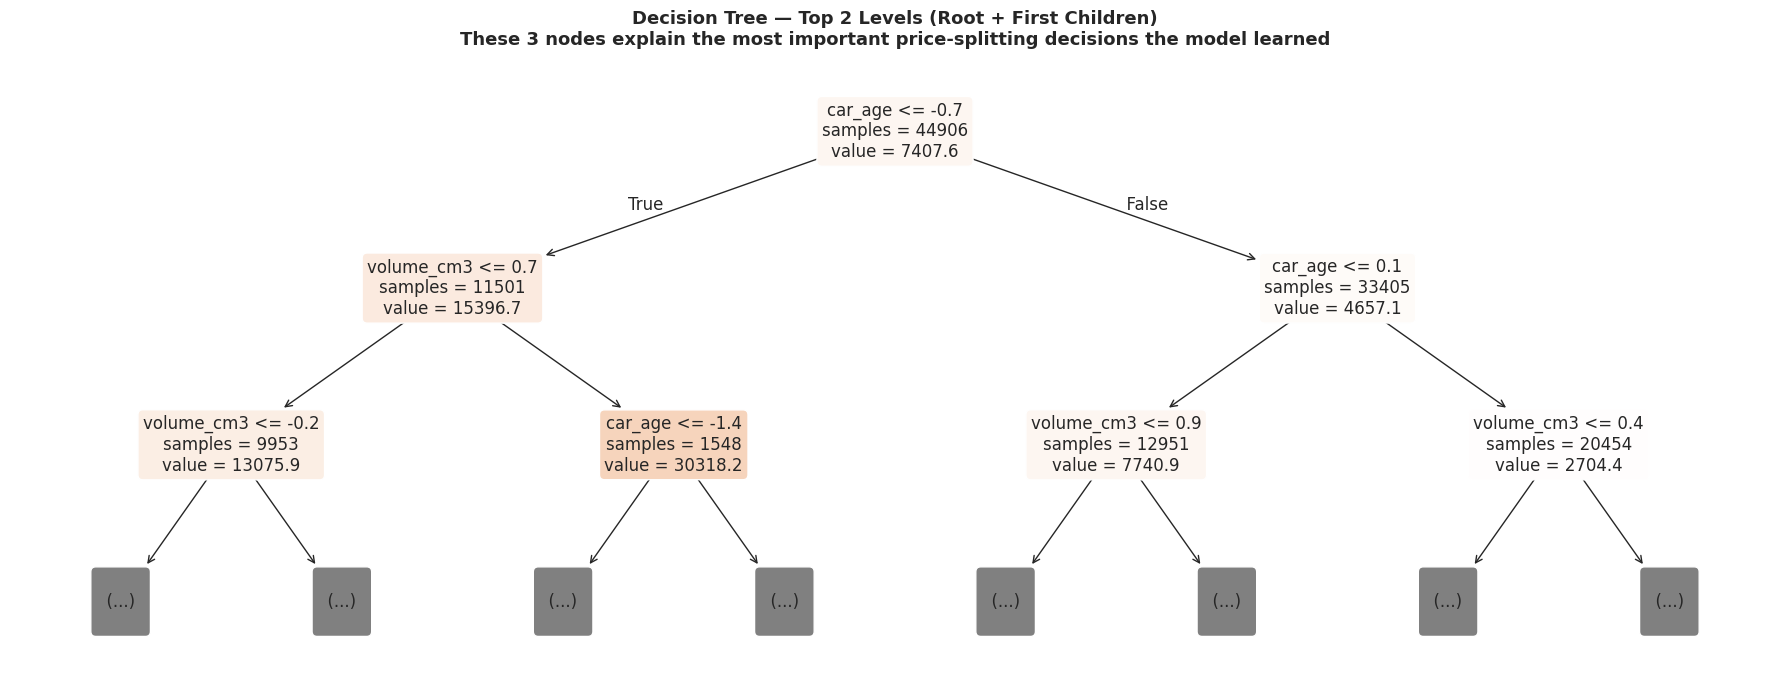

  DECISION TREE — TEXT STRUCTURE
  Left branch = condition TRUE  (feature <= threshold)
  Right branch = condition FALSE (feature >  threshold)
|--- car_age <= -0.74
|   |--- volume_cm3 <= 0.72
|   |   |--- volume_cm3 <= -0.18
|   |   |   |--- volume_cm3 <= -1.93
|   |   |   |   |--- value: [40680.14]
|   |   |   |--- volume_cm3 >  -1.93
|   |   |   |   |--- value: [10461.15]
|   |   |--- volume_cm3 >  -0.18
|   |   |   |--- car_age <= -1.36
|   |   |   |   |--- value: [23865.08]
|   |   |   |--- car_age >  -1.36
|   |   |   |   |--- value: [14535.00]
|   |--- volume_cm3 >  0.72
|   |   |--- car_age <= -1.36
|   |   |   |--- volume_cm3 <= 2.64
|   |   |   |   |--- value: [51814.36]
|   |   |   |--- volume_cm3 >  2.64
|   |   |   |   |--- value: [85734.43]
|   |   |--- car_age >  -1.36
|   |   |   |--- car_age <= -1.11
|   |   |   |   |--- value: [32689.65]
|   |   |   |--- car_age >  -1.11
|   |   |   |   |--- value: [20960.81]
|--- car_age >  -0.74
|   |--- car_age <= 0.12
|   |   |--

In [55]:
# Decision Tree — Visualization
fig, ax = plt.subplots(figsize=(28, 12))
plot_tree(dt_model, feature_names=feature_names, max_depth=4,
          filled=True, rounded=True, fontsize=8, ax=ax, impurity=False, precision=1)
ax.set_title('Decision Tree Regressor — Full Tree (max_depth=4)\n'
             'Root = most important split | Darker colour = more extreme avg price | Value = mean predicted price ($)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(18, 7))
plot_tree(dt_model, feature_names=feature_names, max_depth=2,
          filled=True, rounded=True, fontsize=12, ax=ax2, impurity=False, precision=1)
ax2.set_title('Decision Tree — Top 2 Levels (Root + First Children)\n'
              'These 3 nodes explain the most important price-splitting decisions the model learned',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=' * 72)
print('  DECISION TREE — TEXT STRUCTURE')
print('  Left branch = condition TRUE  (feature <= threshold)')
print('  Right branch = condition FALSE (feature >  threshold)')
print('=' * 72)
print(export_text(dt_model, feature_names=feature_names, max_depth=4, spacing=3))

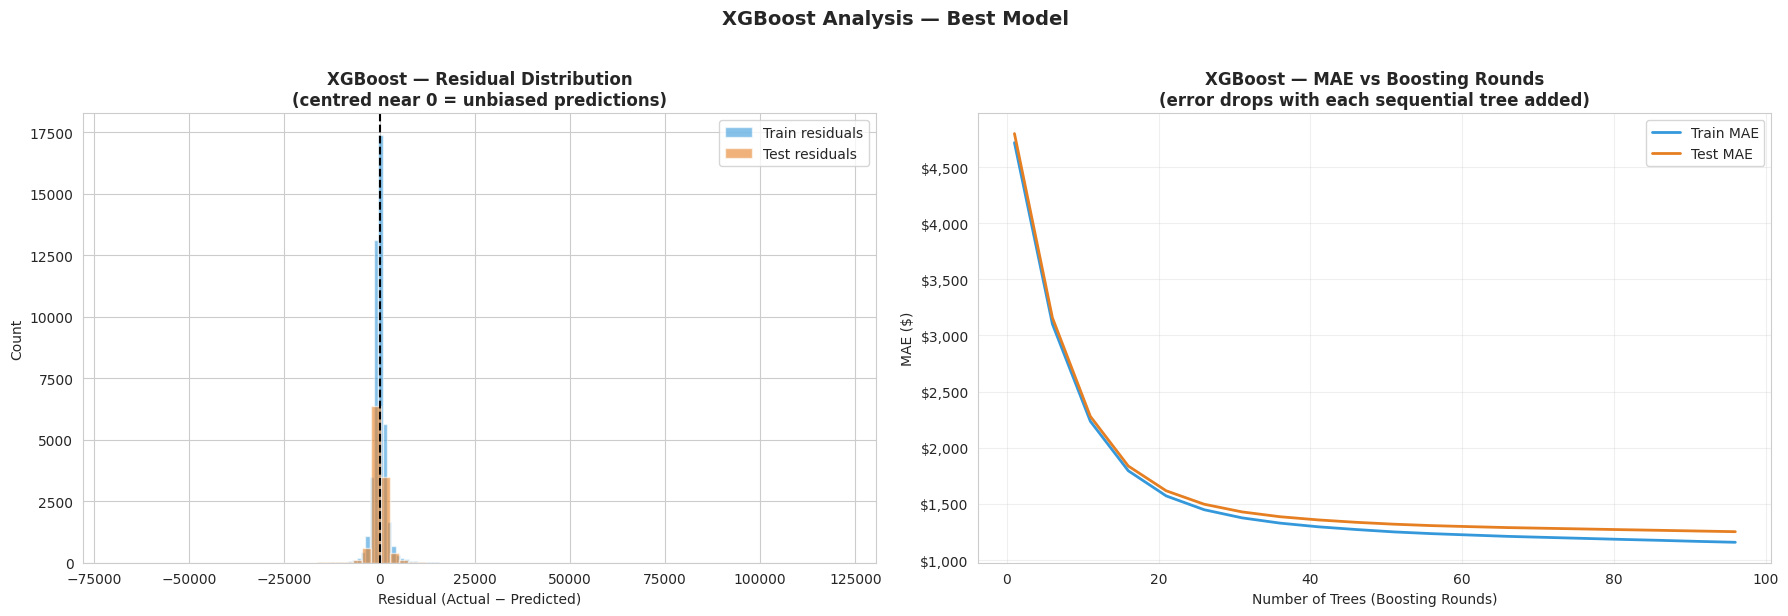

XGBoost residual stats (test set):
  Mean residual:    $       -14  (close to 0 = unbiased)
  Std of residuals: $     2,764
  Min residual:     $   -68,406  (worst underestimate)
  Max residual:     $  +121,001  (worst overestimate)

MAE at round  1:  $     4,798
MAE at round 50:  $     1,336
MAE at round 100: $     1,252
  → Error reduction from boosting: $3,546


In [56]:
# XGBoost — Residual distribution & boosting rounds analysis
xgb_test_pred  = xgb_model.predict(X_test_processed)
xgb_train_pred = xgb_model.predict(X_train_processed)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

residuals_train = y_train_arr - xgb_train_pred
residuals_test  = y_test_arr  - xgb_test_pred

axes[0].hist(residuals_train, bins=80, alpha=0.6, color='#3498db', label='Train residuals')
axes[0].hist(residuals_test,  bins=80, alpha=0.6, color='#e67e22', label='Test residuals')
axes[0].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('XGBoost — Residual Distribution\n(centred near 0 = unbiased predictions)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Residual (Actual − Predicted)')
axes[0].set_ylabel('Count')
axes[0].legend()

staged_mae_train = []
staged_mae_test  = []
for n in range(1, xgb_model.n_estimators + 1, 5):
    pred_tr = xgb_model.predict(X_train_processed, iteration_range=(0, n))
    pred_te = xgb_model.predict(X_test_processed,  iteration_range=(0, n))
    staged_mae_train.append(mean_absolute_error(y_train_arr, pred_tr))
    staged_mae_test.append(mean_absolute_error(y_test_arr,  pred_te))

rounds = list(range(1, xgb_model.n_estimators + 1, 5))
axes[1].plot(rounds, staged_mae_train, color='#3498db', label='Train MAE', linewidth=2)
axes[1].plot(rounds, staged_mae_test,  color='#e67e22', label='Test MAE',  linewidth=2)
axes[1].set_title('XGBoost — MAE vs Boosting Rounds\n(error drops with each sequential tree added)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Trees (Boosting Rounds)')
axes[1].set_ylabel('MAE ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:,.0f}'))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('XGBoost Analysis — Best Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'XGBoost residual stats (test set):')
print(f'  Mean residual:    ${residuals_test.mean():>+10,.0f}  (close to 0 = unbiased)')
print(f'  Std of residuals: ${residuals_test.std():>10,.0f}')
print(f'  Min residual:     ${residuals_test.min():>+10,.0f}  (worst underestimate)')
print(f'  Max residual:     ${residuals_test.max():>+10,.0f}  (worst overestimate)')
print(f'\nMAE at round  1:  ${staged_mae_test[0]:>10,.0f}')
print(f'MAE at round 50:  ${staged_mae_test[9]:>10,.0f}')
print(f'MAE at round 100: ${staged_mae_test[-1]:>10,.0f}')
print(f'  → Error reduction from boosting: ${staged_mae_test[0] - staged_mae_test[-1]:,.0f}')

In [57]:
# Final summary
best_row = metrics_df.loc[metrics_df['test_rmse'].idxmin()]

print('=' * 70)
print('  FINAL MODEL EVALUATION SUMMARY (MAE & RMSE)')
print('=' * 70)
print()
for _, row in metrics_df.iterrows():
    mae_gap  = row['test_mae']  - row['train_mae']
    rmse_gap = row['test_rmse'] - row['train_rmse']
    overfit  = 'YES' if mae_gap > row['train_mae'] * 0.20 else 'NO'
    print(f'  {row["model"]}')
    print(f'    Train  →  MAE: ${row["train_mae"]:>8,.0f}   RMSE: ${row["train_rmse"]:>8,.0f}')
    print(f'    Test   →  MAE: ${row["test_mae"]:>8,.0f}   RMSE: ${row["test_rmse"]:>8,.0f}')
    print(f'    Gap    →  MAE: ${mae_gap:>+8,.0f}   RMSE: ${rmse_gap:>+8,.0f}   Overfitting: {overfit}')
    print()

print('*' * 70)
print(f'  BEST MODEL: {best_row["model"]}')
print(f'  Test RMSE = ${best_row["test_rmse"]:,.0f}  ← PRIMARY METRIC')
print(f'  Test MAE  = ${best_row["test_mae"]:,.0f}  (secondary)')
print('*' * 70)
print()
print('  Business Interpretation:')
print(f'  The {best_row["model"]} model predicts car prices with an average')
print(f'  RMSE of ${best_row["test_rmse"]:,.0f} on unseen data (primary metric).')
print(f'  MAE of ${best_row["test_mae"]:,.0f} on unseen data — predictions are typically within')
print(f'  ${best_row["test_mae"]:,.0f} of the actual price.')
print(f'  This helps a dealership:')
print(f'    - Set competitive and fair prices for inventory')
print(f'    - Identify underpriced/overpriced vehicles in the market')
print(f'    - Make data-driven purchasing decisions at auctions')

  FINAL MODEL EVALUATION SUMMARY (MAE & RMSE)

  Linear Regression
    Train  →  MAE: $   2,637   RMSE: $   5,472
    Test   →  MAE: $   2,676   RMSE: $   5,548
    Gap    →  MAE: $     +39   RMSE: $     +76   Overfitting: NO

  Random Forest
    Train  →  MAE: $   1,504   RMSE: $   3,368
    Test   →  MAE: $   1,595   RMSE: $   3,653
    Gap    →  MAE: $     +91   RMSE: $    +285   Overfitting: NO

  XGBoost
    Train  →  MAE: $   1,149   RMSE: $   2,064
    Test   →  MAE: $   1,248   RMSE: $   2,764
    Gap    →  MAE: $     +99   RMSE: $    +700   Overfitting: NO

**********************************************************************
  BEST MODEL: XGBoost
  Test RMSE = $2,764  ← PRIMARY METRIC
  Test MAE  = $1,248  (secondary)
**********************************************************************

  Business Interpretation:
  The XGBoost model predicts car prices with an average
  RMSE of $2,764 on unseen data (primary metric).
  MAE of $1,248 on unseen data — predictions are typical